<div style="border:solid Chocolate 2px; padding: 40px">

<b>Ярослав, привет!👋</b>

Меня зовут Ольга Бессолицына, ментор, я буду проверять твой проект.

Пожалуйста, не удаляй мои комментарии, они будут особенно полезны для нашей работы в случае повторной проверки проекта. 

Ты можешь найти мои комментарии, обозначенные <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:

<br/>

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> В случае, если решение на отдельном шаге является полностью правильным.
</div>

<br/>

<div class="alert alert-warning">
    <h2> Комментарий ментора <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> В случае, когда решение на отдельном шаге станет еще лучше, если внести небольшие коррективы.
</div>


<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ментора <a class="tocSkip"></h2>

    
<b>На доработку🤔:</b>
 В случае, когда решение на отдельном шаге требует существенной переработки и внесения правок. Напоминаю, что проект не может быть принят с первого раза, если ревью содержит комментарии, рекомендующие доработать шаги.
</div>

# Прогноз оттока клиентов оператора связи "ТелеДом"

Оператор хочет заранее находить абонентов, собирающихся разорвать договор. По данным о договорах, клиентах и услугах строю модель, предсказывающую уход. Стек: pandas, пайплайны scikit-learn, Optuna, phik. Метрика ROC-AUC, целевое значение на тесте не менее 0.85

## 1. Подготовка окружения

Одной ячейкой ставлю пакеты и константы. Считаю на процессоре

In [1]:
%pip install -q catboost phik optuna optuna-integration shap skimpy

import os
import random
import time
import urllib.request
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import phik
import seaborn as sns
import shap

from catboost import CatBoostClassifier, Pool
from optuna.distributions import CategoricalDistribution, FloatDistribution, IntDistribution
from optuna_integration import OptunaSearchCV
from skimpy import clean_columns
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix,
                             precision_recall_curve, roc_auc_score)
from sklearn.model_selection import (StratifiedKFold, cross_val_predict, cross_val_score,
                                     train_test_split)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sqlalchemy import create_engine, inspect

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 310726
DB_URL = 'https://code.s3.yandex.net/data-scientist/ds-plus-final.db'
DATA_SNAPSHOT = pd.Timestamp('2020-02-01')

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

RANDOM_STATE

Note: you may need to restart the kernel to use updated packages.


310726

## 2. Загрузка данных

In [2]:
db_candidates = ['ds-plus-final.db', 'graduation_project/ds-plus-final.db', '/datasets/ds-plus-final.db']
path_to_db = next((candidate for candidate in db_candidates if os.path.exists(candidate)), db_candidates[0])

if not os.path.exists(path_to_db):
    urllib.request.urlretrieve(DB_URL, path_to_db)

path_to_db

'ds-plus-final.db'

Подключаюсь к базе и смотрю, какие таблицы в ней лежат

In [3]:
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)
db_tables = inspect(engine).get_table_names()

pd.Series(db_tables, name='таблица').to_frame()

,таблица
0,contract
1,data_arc
2,data_bulk
3,data_bulk_time
4,data_gas
5,data_temp
6,data_wire
7,data_wire_time
8,internet
9,personal


Таблиц оказалось больше четырёх, загружу только необходимые для проекта

In [4]:
required_tables = ['contract', 'personal', 'internet', 'phone']
missing_tables = sorted(set(required_tables) - set(db_tables))
foreign_tables = sorted(set(db_tables) - set(required_tables))

## 3. Первичный обзор исходных таблиц

Загружаю все четыре таблицы в память и смотрю их в исходном виде, чтобы понимать, в каком формате данные пришли из базы

In [5]:
tables = {name: pd.read_sql(f'SELECT * FROM {name}', engine) for name in required_tables}

contract = tables['contract']
personal = tables['personal']
internet = tables['internet']
phone = tables['phone']

pd.DataFrame({name: df.shape for name, df in tables.items()}, index=['строк', 'столбцов']).T

,строк,столбцов
contract,7043,8
personal,7043,5
internet,5517,8
phone,6361,2


### 3.1 Таблица `contract`

Договоры: даты начала и окончания обслуживания, тип оплаты и суммы платежей

In [6]:
display(contract.head())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


In [7]:
contract.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        7043 non-null   str  
 1   BeginDate         7043 non-null   str  
 2   EndDate           7043 non-null   str  
 3   Type              7043 non-null   str  
 4   PaperlessBilling  7043 non-null   str  
 5   PaymentMethod     7043 non-null   str  
 6   MonthlyCharges    7043 non-null   str  
 7   TotalCharges      7043 non-null   str  
dtypes: str(8)
memory usage: 897.1 KB


Нужно преобразовать типы данных

In [8]:
display(contract.describe(include='all').T)

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
BeginDate,7043,77,2014-02-01,366
EndDate,7043,67,No,5942
Type,7043,3,Month-to-month,3875
PaperlessBilling,7043,2,Yes,4171
PaymentMethod,7043,4,Electronic check,2365
MonthlyCharges,7043,1585,20.05,61
TotalCharges,7043,6658,,11


### 3.2 Таблица `personal`

Персональные данные клиента: пол, признак пенсионера, наличие супруга и детей

In [9]:
display(personal.head())

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [10]:
personal.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str  
 2   SeniorCitizen  7043 non-null   str  
 3   Partner        7043 non-null   str  
 4   Dependents     7043 non-null   str  
dtypes: str(5)
memory usage: 418.1 KB


Нужно преобразовать типы данных

In [11]:
display(personal.describe(include='all').T)

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
SeniorCitizen,7043,2,0,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933


### 3.3 Таблица `internet`

Интернет-услуги: тип подключения и шесть дополнительных сервисов

In [12]:
display(internet.head())

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [13]:
internet.info()

<class 'pandas.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        5517 non-null   str  
 1   InternetService   5517 non-null   str  
 2   OnlineSecurity    5517 non-null   str  
 3   OnlineBackup      5517 non-null   str  
 4   DeviceProtection  5517 non-null   str  
 5   TechSupport       5517 non-null   str  
 6   StreamingTV       5517 non-null   str  
 7   StreamingMovies   5517 non-null   str  
dtypes: str(8)
memory usage: 517.8 KB


Нужно преобразовать типы данных

In [14]:
display(internet.describe(include='all').T)

,count,unique,top,freq
customerID,5517,5517,7590-VHVEG,1
InternetService,5517,2,Fiber optic,3096
OnlineSecurity,5517,2,No,3498
OnlineBackup,5517,2,No,3088
DeviceProtection,5517,2,No,3095
TechSupport,5517,2,No,3473
StreamingTV,5517,2,No,2810
StreamingMovies,5517,2,No,2785


Самые популярные услуги связаны с медиакнонетном. Наименее популярная это поддержка

### 3.4 Таблица `phone`

Телефония: подключение нескольких линий

In [15]:
display(phone.head())

,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [16]:
phone.info()

<class 'pandas.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerId     6361 non-null   str  
 1   MultipleLines  6361 non-null   str  
dtypes: str(2)
memory usage: 177.0 KB


Нужно преобразовать типы данных

In [17]:
display(phone.describe(include='all').T)

,count,unique,top,freq
CustomerId,6361,6361,5575-GNVDE,1
MultipleLines,6361,2,No,3390


<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> данные загружены корректно

Свожу в одну таблицу то, что нужно проверить до объединения. Дальше проверю, как называется столбец с ID, сколько пропусков, есть ли полные дубликаты строк и повторяющиеся ID клиентов

In [18]:
pd.DataFrame([
    {
        'таблица': name,
        'колонка ID': df.columns[0],
        'пропусков': int(df.isna().sum().sum()),
        'дубликатов строк': int(df.duplicated().sum()),
        'дубликатов ID': int(df[df.columns[0]].duplicated().sum()),
    }
    for name, df in tables.items()
]).set_index('таблица')

,колонка ID,пропусков,дубликатов строк,дубликатов ID
таблица,,,,
contract,customerID,0,0,0
personal,customerID,0,0,0
internet,customerID,0,0,0
phone,CustomerId,0,0,0


Проверяю ключи явно, до объединения: совпадают ли списки клиентов в `contract` и `personal` и правда ли, что записи об услугах это подмножества договоров. Если где-то всплывут "лишние" ID, объединение молча потеряет часть клиентов

In [19]:
contract_ids = set(contract['customerID'])

pd.Series({
    'клиентов в contract': len(contract_ids),
    'ID personal нет в contract': len(set(personal['customerID']) - contract_ids),
    'ID contract нет в personal': len(contract_ids - set(personal['customerID'])),
    'ID internet нет в contract': len(set(internet['customerID']) - contract_ids),
    'ID phone нет в contract': len(set(phone['CustomerId']) - contract_ids),
    'клиентов без интернета и телефонии': len(contract_ids - set(internet['customerID']) - set(phone['CustomerId'])),
}, name='значение').to_frame()

,значение
клиентов в contract,7043
ID personal нет в contract,0
ID contract нет в personal,0
ID internet нет в contract,0
ID phone нет в contract,0
клиентов без интернета и телефонии,0


Заодно проверяю то, что дальше придётся приводить к нормальным типам: читаются ли даты без потерь и правда ли они помесячные (все с первого числа), а следом, сколько в суммах платежей строк-заглушек с одиночным пробелом

In [20]:
begin_dates = pd.to_datetime(contract['BeginDate'], errors='coerce')
end_dates = pd.to_datetime(contract.loc[contract['EndDate'] != 'No', 'EndDate'], errors='coerce')

pd.Series({
    'BeginDate не распознано как дата': int(begin_dates.isna().sum()),
    'EndDate не распознано как дата': int(end_dates.isna().sum()),
    'дат начала не с первого числа': int((begin_dates.dt.day != 1).sum()),
    'дат расторжения не с первого числа': int((end_dates.dt.day != 1).sum()),
}, name='значение').to_frame()

,значение
BeginDate не распознано как дата,0
EndDate не распознано как дата,0
дат начала не с первого числа,0
дат расторжения не с первого числа,0


In [21]:
pd.Series({
    'TotalCharges — одиночный пробел': int((contract['TotalCharges'] == ' ').sum()),
    'TotalCharges не приводится к числу': int(pd.to_numeric(contract['TotalCharges'], errors='coerce').isna().sum()),
    'MonthlyCharges не приводится к числу': int(pd.to_numeric(contract['MonthlyCharges'], errors='coerce').isna().sum()),
}, name='значение').to_frame()

,значение
TotalCharges — одиночный пробел,11
TotalCharges не приводится к числу,11
MonthlyCharges не приводится к числу,0


**Промежуточный вывод по разделу**

- `contract` 7043 строки, `personal` 7043, `internet` 5517, `phone` 6361. В `EndDate` у 5942 клиентов стоит `No`, у 1101 дата расторжения
- Всё пришло текстом: платежи приведу к числам, даты к `datetime`, ответы `Yes`/`No` во флаги `bool`
- Даты читаются без потерь и все приходятся на первое число месяца, срок жизни договора можно считать в месяцах
- 11 строк в `TotalCharges` содержат одиночный пробел `' '`, поэтому `isna()` их не видит
- Дубликатов нет ни по строкам, ни по ID, таблицы соединяются один к одному. Ключ в `phone` называется `CustomerId`, переименую
- Разное число строк это не потеря данных, а клиенты без одной из услуг. Пропуски после объединения читать как услуга не подключена

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> хорошо

## 4. Предобработка исходных таблиц

Привожу имена столбцов к snake_case, типы к подходящим и ищу аномалии. Пропуски в `total_charges` пока не заполняю

Названия столбцов привожу к snake_case функцией `clean_columns` из `skimpy`. Дальше по работе имена в едином стиле, и в `phone` заодно чинится ключ `CustomerId`

In [22]:
tables = {name: clean_columns(frame) for name, frame in tables.items()}

contract = tables['contract']
personal = tables['personal']
internet = tables['internet']
phone = tables['phone']

display(pd.Series({name: ', '.join(frame.columns) for name, frame in tables.items()},
                  name='столбцы').to_frame())

pd.Series({name: [column for column in frame.columns if column != column.lower()]
           for name, frame in tables.items()},
          name='осталось не в snake_case', dtype=object).to_frame()

,столбцы
contract,"customer_id, begin_date, end_date, type, paper..."
personal,"customer_id, gender, senior_citizen, partner, ..."
internet,"customer_id, internet_service, online_security..."
phone,"customer_id, multiple_lines"


,осталось не в snake_case
contract,[]
personal,[]
internet,[]
phone,[]


<div class="alert alert-warning">
    <h2> Комментарий ментора <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b>
есть неплохая библиотека для выполнения  рутинных операций в пандасе - https://pypi.org/project/skimpy/. Там же есть функция clean_column() котороая в одно действие выполняет приведение названий колонок к соответствующему виду.
       
Рекомендую ознакомиться.

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>
Переписал приведение имён на clean_columns из skimpy, ручной словарь из 21 пары убран. Результат совпал столбец в столбец.
</div>

<div class="alert alert-block alert-danger">
<h2> Комментарий ментора <a class="tocSkip"></h2>

    
<b>На доработку🤔:</b> удалять лучше после анализа, сейчас непонятно на каком основании удаление - нет ни статистик, ни графиков, ни корреляции. Нужно или обосновать здесь (не. только словами) или перенести после анализа

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>
Удаление перенёс из раздела 4 в новый подраздел 6.3, после корреляционного анализа

В `contract` даты перевожу в `datetime`, оба платежа в числа, одиннадцать пробелов в `total_charges` становятся `NaN`, `paperless_billing` в `bool`. `end_date` оставляю текстом, из него при объединении соберу целевой признак

In [23]:
contract['begin_date'] = pd.to_datetime(contract['begin_date'])
contract['monthly_charges'] = contract['monthly_charges'].astype(float)
contract['total_charges'] = pd.to_numeric(contract['total_charges'], errors='coerce')
contract['paperless_billing'] = contract['paperless_billing'].eq('Yes')

display(contract.dtypes.to_frame('тип'))
display(pd.Series({
    'пропусков в begin_date': int(contract['begin_date'].isna().sum()),
    'пропусков в monthly_charges': int(contract['monthly_charges'].isna().sum()),
    'пропусков в total_charges': int(contract['total_charges'].isna().sum()),
}, name='значение').to_frame())

,тип
customer_id,str
begin_date,datetime64[us]
end_date,str
type,str
paperless_billing,bool
payment_method,str
monthly_charges,float64
total_charges,float64


,значение
пропусков в begin_date,0
пропусков в monthly_charges,0
пропусков в total_charges,11


В `personal` перевожу в `bool` три признака: `senior_citizen` со значениями 0 и 1, `partner` и `dependents`. `gender` остаётся текстовой категорией

In [24]:
personal['senior_citizen'] = personal['senior_citizen'].eq('1')
personal['partner'] = personal['partner'].eq('Yes')
personal['dependents'] = personal['dependents'].eq('Yes')

display(personal.dtypes.to_frame('тип'))
display(personal.head())

,тип
customer_id,str
gender,str
senior_citizen,bool
partner,bool
dependents,bool


,customer_id,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,False,True,False
1,5575-GNVDE,Male,False,False,False
2,3668-QPYBK,Male,False,False,False
3,7795-CFOCW,Male,False,False,False
4,9237-HQITU,Female,False,False,False


В `internet` шесть дополнительных сервисов перевожу в `bool` одним списком, он пригодится и дальше

In [25]:
internet_addons = ['online_security', 'online_backup', 'device_protection', 'tech_support',
                   'streaming_tv', 'streaming_movies']

internet[internet_addons] = internet[internet_addons].eq('Yes')

internet.dtypes.to_frame('тип')

,тип
customer_id,str
internet_service,str
online_security,bool
online_backup,bool
device_protection,bool
tech_support,bool
streaming_tv,bool
streaming_movies,bool


Перевожу в `bool` единственную услугу таблицы, `multiple_lines`

In [26]:
phone['multiple_lines'] = phone['multiple_lines'].eq('Yes')

phone.dtypes.to_frame('тип')

,тип
customer_id,str
multiple_lines,bool


Платежи стали числами, описательная статистика по ним теперь имеет смысл

In [27]:
contract.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
monthly_charges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.8500,118.75
total_charges,7032.0,2118.621822,2112.736199,19.05,439.745,1345.275,3239.3175,9221.38


Дальше ищу аномалии, важные именно для телекома. Сначала смотрю, не встречаются ли отрицательные или нулевые платежи. У оператора связи, возможно, такой абонент это либо ошибка выгрузки, либо служебный договор. Потом разбираюсь, кто эти одиннадцать клиентов с пропавшей суммой платежей. По условию задачи данные актуальны на 1 февраля 2020 года и я ожидаю, что все пропуски приходятся ровно на договоры, заключённые в день среза. Такие абоненты, наверно, просто не успели получить первый счёт

In [28]:
pd.Series({
    'monthly_charges отрицательных': int((contract['monthly_charges'] < 0).sum()),
    'monthly_charges нулевых': int((contract['monthly_charges'] == 0).sum()),
    'total_charges отрицательных': int((contract['total_charges'] < 0).sum()),
    'total_charges нулевых': int((contract['total_charges'] == 0).sum()),
    'всего договоров': len(contract),
}, name='значение').to_frame()

,значение
monthly_charges отрицательных,0
monthly_charges нулевых,0
total_charges отрицательных,0
total_charges нулевых,0
всего договоров,7043


In [29]:
missing_total = contract['total_charges'].isna()
started_at_snapshot = contract['begin_date'] == DATA_SNAPSHOT

pd.Series({
    'пропусков в total_charges': int(missing_total.sum()),
    'договоров, начатых 2020-02-01': int(started_at_snapshot.sum()),
    'пропусков среди этих договоров': int((missing_total & started_at_snapshot).sum()),
    'пропусков с более ранней датой начала': int((missing_total & ~started_at_snapshot).sum()),
    'пропусков у расторгнутых договоров': int((missing_total & (contract['end_date'] != 'No')).sum()),
}, name='значение').to_frame()

,значение
пропусков в total_charges,11
"договоров, начатых 2020-02-01",11
пропусков среди этих договоров,11
пропусков с более ранней датой начала,0
пропусков у расторгнутых договоров,0


Сходится ли накопленная сумма с длительностью договора? Считаю, сколько месяцев клиент обслуживался от даты начала до расторжения, а для действующих договоров до среза 1 февраля 2020 года, и умножаю на месячный платёж. Оценка заведомо грубая, она не учитывает ни смену тарифа, ни подключение услуг в середине срока, поэтому смотрю на неё как на проверку порядка величин

In [30]:
billed_until = pd.to_datetime(contract['end_date'].where(contract['end_date'] != 'No')).fillna(DATA_SNAPSHOT)
months_served = ((billed_until.dt.year - contract['begin_date'].dt.year) * 12
                 + (billed_until.dt.month - contract['begin_date'].dt.month))
rough_total = months_served * contract['monthly_charges']

months_served.describe().to_frame('месяцев обслуживания')

,месяцев обслуживания
count,7043.000000
mean,29.495385
std,22.446726
min,0.000000
25%,9.000000
50%,25.000000
75%,48.000000
max,76.000000


In [31]:
charges_ratio = (contract['total_charges'] / rough_total).dropna()
deviation_percent = 100 * (charges_ratio - 1).abs()

display(charges_ratio.describe().round(3).to_frame('total_charges к грубой оценке'))
display(pd.DataFrame({
    'клиентов': [int((deviation_percent > level).sum()) for level in [5, 10, 20]],
    'доля, %': [round(100 * (deviation_percent > level).mean(), 1) for level in [5, 10, 20]],
}, index=['расхождение больше 5%', 'расхождение больше 10%', 'расхождение больше 20%']))

,total_charges к грубой оценке
count,7032.000
mean,1.028
std,0.034
min,1.000
25%,1.000
50%,1.010
75%,1.060
max,1.100


,клиентов,"доля, %"
расхождение больше 5%,2003,28.5
расхождение больше 10%,252,3.6
расхождение больше 20%,0,0.0


**Промежуточный вывод по разделу**

- Имена столбцов приведены к snake_case одним вызовом `clean_columns` из `skimpy`, ключ в `phone` починен заодно
- Типы приведены к рабочим, `end_date` остался текстом
- Отрицательных и нулевых платежей нет
- 11 пропусков в `total_charges` это новые клиенты. Все приходятся на договоры, начатые 1 февраля 2020 года, в день среза, и все они действующие
- Накопленная сумма согласуется с длительностью. Отношение `total_charges` к оценке "месяцы x месячный платёж" лежит между 1.000 и 1.100 при медиане 1.010, расхождения больше 20% нет ни у одного клиента. Аномалий нет, никого не удаляю

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> согласна

## 5. Объединение таблиц и целевой признак

Собираю четыре таблицы в одну со строкой на клиента: закрываю вопрос с пропусками в `total_charges`, соединяю по `customer_id`, фиксирую флаг `has_internet`, заполняю пропуски у неподключённых услуг, выделяю целевой признак и добавляю оба признака срока

Возвращаюсь к одиннадцати клиентам с пропущенной суммой платежей. В разделе 4 видно, что это не порча данных: все одиннадцать заключили договор 1 февраля 2020 года, в день среза, и первого счёта ещё не получили. Заполнить пропуск нулём формально можно, но такая строка не описывает ничего, кроме того, что данные по клиенту ещё не накопились: нулевая сумма платежей, нулевой срок жизни договора и заранее известный статус уйти он физически не успел. Пользы для модели в этом нет, поэтому строки удаляю т.к. это всего 0.16% выборки

In [32]:
contracts_before = len(contract)
contract = contract.dropna(subset=['total_charges']).reset_index(drop=True)

pd.Series({
    'договоров до удаления': contracts_before,
    'удалено строк': contracts_before - len(contract),
    'договоров осталось': len(contract),
    'пропусков в total_charges': int(contract['total_charges'].isna().sum()),
}, name='значение').to_frame()

,значение
договоров до удаления,7043
удалено строк,11
договоров осталось,7032
пропусков в total_charges,0


Собираю таблицу пошагово, а не одним выражением. После каждого присоединения я хочу видеть, что размер таблицы не поехал

In [33]:
data = contract.merge(personal, on='customer_id', how='left', validate='one_to_one')

pd.Series({
    'строк': len(data),
    'столбцов': data.shape[1],
    'уникальных клиентов': data['customer_id'].nunique(),
    'пропусков в таблице': int(data.isna().sum().sum()),
}, name='после personal').to_frame()

,после personal
строк,7032
столбцов,12
уникальных клиентов,7032
пропусков в таблице,0


Далее интернет услуги. Записей в `internet` меньше, чем клиентов, поэтому число строк остаться должно прежним

In [34]:
data = data.merge(internet, on='customer_id', how='left', validate='one_to_one')

pd.Series({
    'строк': len(data),
    'столбцов': data.shape[1],
    'уникальных клиентов': data['customer_id'].nunique(),
    'пропусков в таблице': int(data.isna().sum().sum()),
}, name='после internet').to_frame()

,после internet
строк,7032
столбцов,19
уникальных клиентов,7032
пропусков в таблице,10640


Телефония, последний столбец услуг

In [35]:
data = data.merge(phone, on='customer_id', how='left', validate='one_to_one')

pd.Series({
    'строк': len(data),
    'столбцов': data.shape[1],
    'уникальных клиентов': data['customer_id'].nunique(),
    'пропусков в таблице': int(data.isna().sum().sum()),
}, name='после phone').to_frame()

,после phone
строк,7032
столбцов,20
уникальных клиентов,7032
пропусков в таблице,11320


<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> единый датасет собран верно

Считаю пропуски по столбцам услуг и собираю список из семи столбцов, которые хранятся флагами. Здесь же фиксирую флаг `has_internet`: клиент есть в таблице `internet`

In [36]:
addon_columns = internet_addons + ['multiple_lines']
data['has_internet'] = data['online_security'].notna()

display(data[addon_columns].isna().sum().to_frame('пропусков'))
display(pd.Series({
    'клиентов без интернета': int((~data['has_internet']).sum()),
    'клиентов без телефонии': int(data['multiple_lines'].isna().sum()),
    'пропусков во всей таблице': int(data.isna().sum().sum()),
}, name='значение').to_frame())

,пропусков
online_security,1520
online_backup,1520
device_protection,1520
tech_support,1520
streaming_tv,1520
streaming_movies,1520
multiple_lines,680


,значение
клиентов без интернета,1520
клиентов без телефонии,680
пропусков во всей таблице,11320


Заполняю пропуски значением `False`: здесь это не "неизвестно", а "услуга не подключена". Столбцам возвращаю тип `bool`. В `internet_service` пропуск означает то же самое, ставлю `No`. Флаг `has_internet` зафиксирован до заполнения, иначе он растворился бы в нулях

In [37]:
data[addon_columns] = data[addon_columns].fillna(False).astype(bool)
data['internet_service'] = data['internet_service'].fillna('No')

display(data['has_internet'].value_counts().to_frame('клиентов'))
display(data['multiple_lines'].value_counts().to_frame('клиентов'))

int(data.isna().sum().sum())

,клиентов
has_internet,
True,5512
False,1520


,клиентов
multiple_lines,
False,4065
True,2967


0

Выделяю целевой признак. В `end_date` у действующих клиентов стоит `No`, а у ушедших дата расторжения, поэтому сам факт наличия даты и есть ответ. `churn` `True`, если договор расторгнут, и `False`, если клиент ещё с оператором

In [38]:
data['churn'] = data['end_date'] != 'No'

churn_stats = pd.concat([
    data['churn'].value_counts().rename('клиентов'),
    data['churn'].value_counts(normalize=True).mul(100).round(1).rename('доля, %'),
], axis=1).rename(index={False: 'остались', True: 'ушли'})

churn_stats

,клиентов,"доля, %"
churn,,
остались,5931,84.3
ушли,1101,15.7


<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b>таргет выделен верно

Добавляю признак длительность контракта. Считаю его так же, как считал срок обслуживания в разделе 4: у ушедших клиентов от даты начала договора до даты расторжения, у действующих до среза 1 февраля 2020 года. Беру разницу в полных месяцах, и это корректно, потому что в разделе 3 я проверил: все даты в данных приходятся на первое число месяца

In [39]:
contract_end = pd.to_datetime(data['end_date'].where(data['end_date'] != 'No')).fillna(DATA_SNAPSHOT)
data['contract_duration'] = ((contract_end.dt.year - data['begin_date'].dt.year) * 12
                             + (contract_end.dt.month - data['begin_date'].dt.month))

data['contract_duration'].describe().to_frame('длительность контракта, месяцев')

,"длительность контракта, месяцев"
count,7032.000000
mean,29.541524
std,22.433916
min,1.000000
25%,9.000000
50%,25.000000
75%,48.000000
max,76.000000


У ушедших `contract_duration` посчитан по фактическому `end_date`, полю, из которого собран `churn`. ТЗ такой признак разрешает, но offline-оценка от него оптимистична

Отсюда правило сборки признаков. `begin_date` и `end_date` в `X` не попадают никогда, из их производных допускаются только названные поимённо, и не больше одной. Иначе дата ухода восстанавливается арифметикой по паре "дата начала + длительность". Список признаков собираю явным перечислением в разделе 8

Добавляю второй временной признак, `life_span`, срок жизни клиента в днях. У ушедших до даты расторжения, у действующих до среза 1 февраля 2020 года. В отличие от месяцев дневная шкала различает клиентов внутри одного месяца, поэтому в матрицу признаков пойдёт именно она, а `contract_duration` остаётся для разведочного анализа

**Цена признака.** У ушедших срок считается до `end_date`, из которого собран `churn`, а у действующих граница одна на всех. Поэтому число дней подсказывает, приходится ли конец срока на дату среза, а это и есть ответ. Все метрики ниже оптимистичны на эту величину

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> согласна

In [40]:
data['life_span'] = (contract_end - data['begin_date']).dt.days

display(data['life_span'].describe().round(1).to_frame('срок жизни клиента, дней'))

data[['begin_date', 'end_date', 'contract_duration', 'life_span']].head()

,"срок жизни клиента, дней"
count,7032.0
mean,900.0
std,682.7
min,28.0
25%,276.0
50%,761.0
75%,1461.0
max,2314.0


,begin_date,end_date,contract_duration,life_span
0,2020-01-01,No,1,31
1,2017-04-01,No,34,1036
2,2019-10-01,No,4,123
3,2016-05-01,No,45,1371
4,2019-09-01,No,5,153


Смотрю на собранную таблицу целиком

In [41]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7032 non-null   str           
 1   begin_date         7032 non-null   datetime64[us]
 2   end_date           7032 non-null   str           
 3   type               7032 non-null   str           
 4   paperless_billing  7032 non-null   bool          
 5   payment_method     7032 non-null   str           
 6   monthly_charges    7032 non-null   float64       
 7   total_charges      7032 non-null   float64       
 8   gender             7032 non-null   str           
 9   senior_citizen     7032 non-null   bool          
 10  partner            7032 non-null   bool          
 11  dependents         7032 non-null   bool          
 12  internet_service   7032 non-null   str           
 13  online_security    7032 non-null   bool          
 14  online_backup      

In [42]:
display(data.head())

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,...,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,has_internet,churn,contract_duration,life_span
0,7590-VHVEG,2020-01-01,No,Month-to-month,True,Electronic check,29.85,31.04,Female,False,...,True,False,False,False,False,False,True,False,1,31
1,5575-GNVDE,2017-04-01,No,One year,False,Mailed check,56.95,2071.84,Male,False,...,False,True,False,False,False,False,True,False,34,1036
2,3668-QPYBK,2019-10-01,No,Month-to-month,True,Mailed check,53.85,226.17,Male,False,...,True,False,False,False,False,False,True,False,4,123
3,7795-CFOCW,2016-05-01,No,One year,False,Bank transfer (automatic),42.30,1960.60,Male,False,...,False,True,True,False,False,False,True,False,45,1371
4,9237-HQITU,2019-09-01,No,Month-to-month,True,Electronic check,70.70,353.50,Female,False,...,False,False,False,False,False,False,True,False,5,153


**Промежуточный вывод по разделу**

- Таблица 7032 строки и 24 столбца, ни одного пропуска. Одиннадцать новичков без статистики удалены, это 0.16% выборки
- Три `merge` с `validate='one_to_one'` прошли без ошибок, пропуски услуг закрыты значением `False`, флаг `has_internet` зафиксирован до заполнения
- Классы несбалансированы. Ушли 1101 клиент, 15.7%, остались 5931, 84.3%. Значит, нужен `stratify` и учёт веса классов, а метрика ROC-AUC, а не accuracy
- `contract_duration` создан. Медиана 25 месяцев, разброс от 1 до 76. `life_span` тот же срок в днях. Медиана 761, разброс от 28 до 2314
- Оба признака срока ретроспективны, у дневной шкалы сильнее. Прочие производные `begin_date` в `X` не пойдут

## 6. Корреляционный анализ и кандидаты новых признаков

Признаки разнотипные, коэффициент Пирсона не подходит. Беру phik. Он считает связь любой пары по шкале от 0 до 1, числовые столбцы разбивает на интервалы сам, знака у коэффициента нет

### 6.1 Матрица корреляций

Считаю матрицу без `customer_id` и двух дат. `churn` собран из `end_date`, и связь была бы избыточной. Интервальными объявляю `monthly_charges`, `total_charges`, `contract_duration` и `life_span`

In [43]:
correlation_columns = data.columns.drop(['customer_id', 'begin_date', 'end_date'])
interval_columns = ['monthly_charges', 'total_charges', 'contract_duration', 'life_span']

phik_matrix = data[correlation_columns].phik_matrix(interval_cols=interval_columns)

phik_matrix.shape

(21, 21)

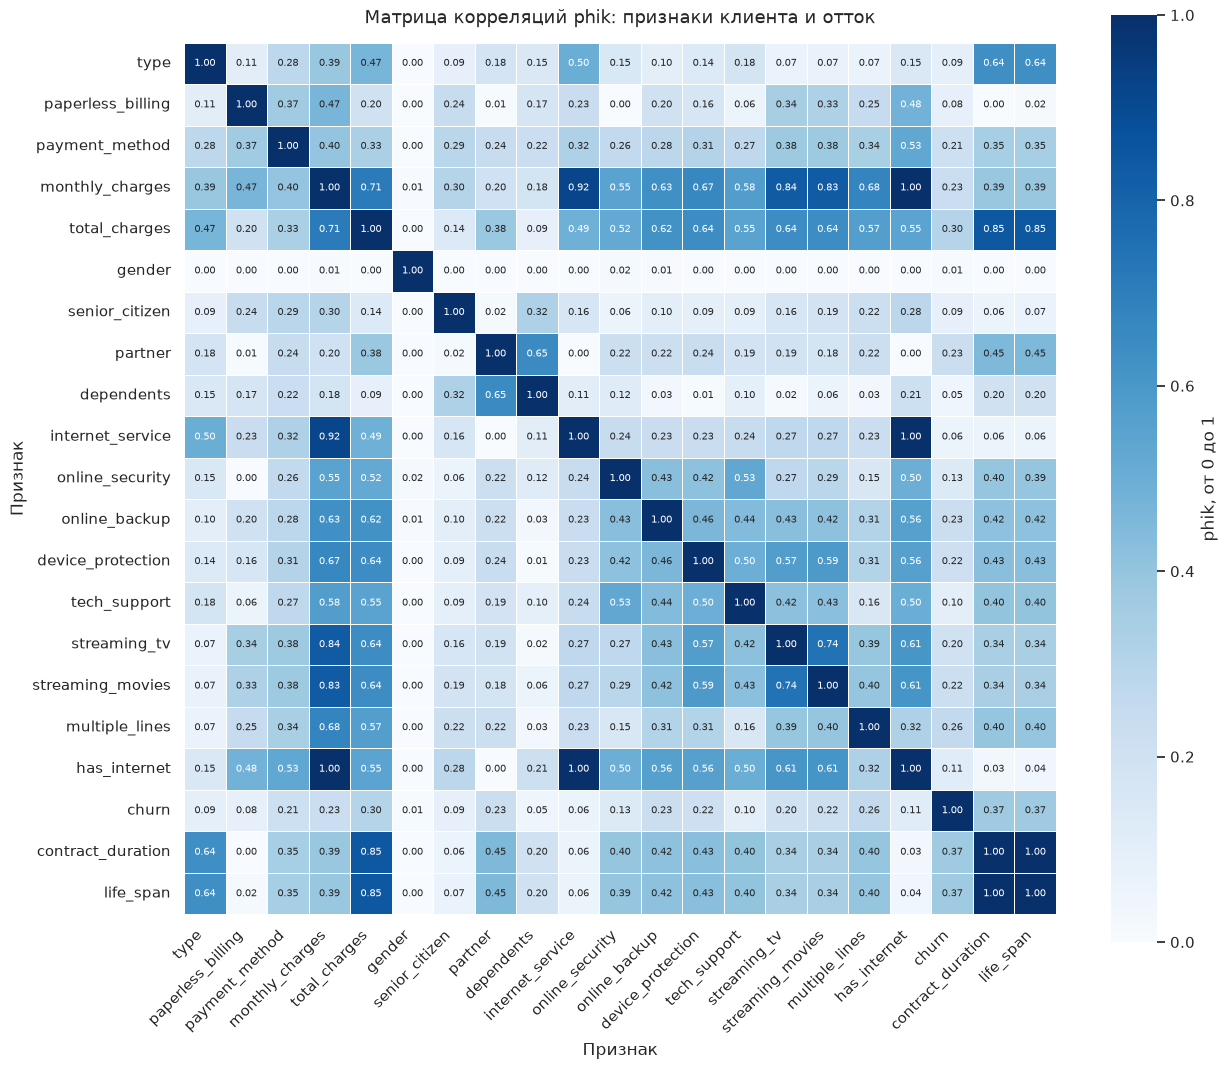

In [44]:
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', annot_kws={'size': 7}, cmap='Blues',
            vmin=0, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'phik, от 0 до 1'}, ax=ax)
ax.set_title('Матрица корреляций phik: признаки клиента и отток', fontsize=13, pad=14)
ax.set_xlabel('Признак')
ax.set_ylabel('Признак')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

Выписываю самые сильные пары, `churn` из них убираю

In [45]:
feature_matrix = phik_matrix.drop(index='churn', columns='churn')
upper_triangle = np.triu(np.ones(feature_matrix.shape, dtype=bool), k=1)
feature_pairs = (feature_matrix.where(upper_triangle).stack().dropna()
                 .rename_axis(['признак 1', 'признак 2']).sort_values(ascending=False))

display(feature_pairs.head(15).round(3).to_frame('phik'))

len(feature_pairs)

phik
признак 1         признак 2               
internet_service  has_internet       1.000
contract_duration life_span          1.000
monthly_charges   has_internet       0.999
                  internet_service   0.919
total_charges     life_span          0.848
                  contract_duration  0.847
monthly_charges   streaming_tv       0.836
                  streaming_movies   0.833
streaming_tv      streaming_movies   0.743
monthly_charges   total_charges      0.711
                  multiple_lines     0.677
                  device_protection  0.668
partner           dependents         0.652
total_charges     streaming_movies   0.644
                  streaming_tv       0.643

190

Самые сильные связи не с целью, а между самими признаками.

- **Пар со значением 1.000 две.** `internet_service` с `has_internet`: флаг выведен из типа, поэтому phik максимален. `life_span` с `contract_duration`: один и тот же срок в днях и месяцах, а внутри интервалов phik они совпадают
- **Флаг подключения почти совпадает с платежом.** `monthly_charges` с `has_internet` 0.999 и с `internet_service` 0.919, без интернета счёт упирается в нижний край шкалы
- **Биллинг замыкает денежный блок.** `total_charges` с `life_span` 0.848 и с `contract_duration` 0.847, дальше платёж со `streaming_tv` 0.836 и со `streaming_movies` 0.833
- **Семейные признаки дублируют друг друга,** `partner` с `dependents` 0.652

Мультиколлинеарность выраженная. Важность буду читать группами, а дубли и слабые признаки отсеиваю в 6.3

### 6.2 Связь признаков с оттоком

In [46]:
churn_correlation = phik_matrix['churn'].drop('churn').sort_values(ascending=False)

churn_correlation.round(3).to_frame('phik с churn')

,phik с churn
life_span,0.374
contract_duration,0.371
total_charges,0.304
multiple_lines,0.261
online_backup,0.230
partner,0.228
monthly_charges,0.225
streaming_movies,0.222
device_protection,0.219
payment_method,0.214


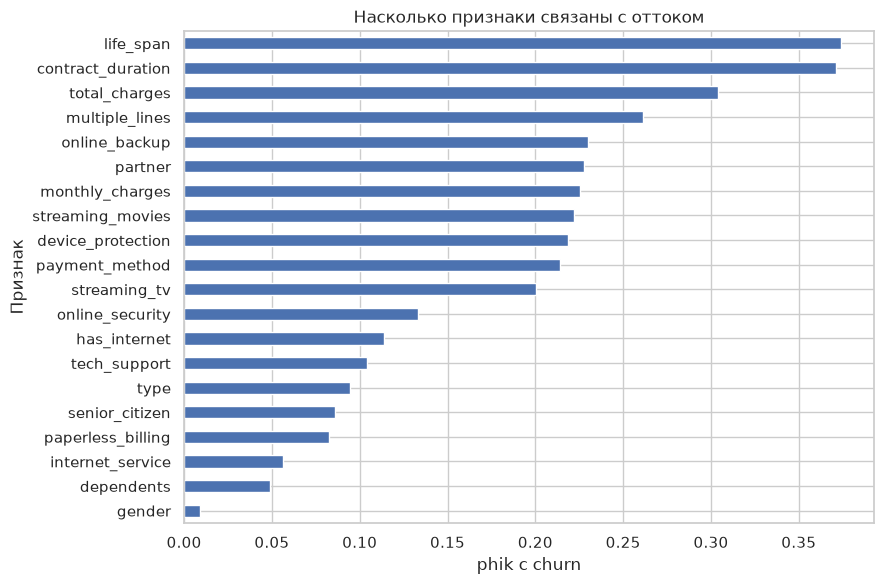

In [47]:
fig, ax = plt.subplots(figsize=(9, 6))
churn_correlation.sort_values().plot.barh(ax=ax, color='#4C72B0')
ax.set_title('Насколько признаки связаны с оттоком')
ax.set_xlabel('phik с churn')
ax.set_ylabel('Признак')
plt.tight_layout()
plt.show()

Сильных связей с целью нет ни одной, максимум по таблице 0.374.

- **Верх списка признаки срока.** `life_span` 0.374, `contract_duration` 0.371, `total_charges` 0.304. Читается осторожно, у ушедших срок посчитан до даты расторжения. Дневная шкала обгоняет месячную всего на 0.003
- **Услуги и платежи в узком коридоре 0.20–0.26,** лучший `multiple_lines` 0.261
- **Низ списка:** `type` 0.095, `senior_citizen` 0.086, `paperless_billing` 0.083, а совсем внизу `internet_service` 0.056, `dependents` 0.049 и `gender` 0.009. Эти три разбираю в 6.3

Отток не объясняется одним фактором, качество даст сложение слабых сигналов, то есть ансамблевые модели

<div class="alert alert-success">
<h2> Комментарий ментора<a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Отлично, все верно, на будущее, полезные ссылки - проверка важности признаков по модели это только один из способов (корреляция в том числе). Используют также аналитические методы проверки гипотез. 

Есть несколько инструментов для отбора признаков, подробнее можно посмотреть в данной статье (Отбор признаков в задачах машинного обучения): https://habr.com/ru/post/550978/

В библиотеке sklearn есть методы mutual_info_regression и mutual_info_classif соответственно для регрессии и классификации.
https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html#sklearn.feature_selection.mutual_info_classif

### 6.3 Отсев признаков

Три признака стоят в самом низу списка связи с оттоком. Перед удалением проверяю их числом: связь с целью, размах доли ушедших по категориям и самая сильная связь с признаком, который остаётся

In [48]:
dropped_features = ['internet_service', 'dependents', 'gender']
kept_features = phik_matrix.columns.drop(dropped_features + ['churn'])
churn_rates = {feature: 100 * data.groupby(feature)['churn'].mean() for feature in dropped_features}

pd.DataFrame([
    {'признак': feature,
     'phik с churn': phik_matrix.loc[feature, 'churn'],
     'размах доли ушедших, п.п.': rates.max() - rates.min(),
     'ближайший оставшийся': phik_matrix.loc[feature, kept_features].idxmax(),
     'phik с ним': phik_matrix.loc[feature, kept_features].max()}
    for feature, rates in churn_rates.items()
]).set_index('признак').round(3)

,phik с churn,"размах доли ушедших, п.п.",ближайший оставшийся,phik с ним
признак,,,,
internet_service,0.056,8.692,has_internet,1.000
dependents,0.049,2.673,partner,0.652
gender,0.009,0.986,online_security,0.017


- **`internet_service` и `has_internet` связаны односторонне,** phik 1.000: флаг выведен из типа, обратно тип по флагу не восстановить. Связь с оттоком у типа ниже, 0.056 против 0.114 у флага. Из размаха 8.7 п.п. (DSL 14.3%, Fiber optic 19.2%, без интернета 10.5%) флаг держит 6.5 п.п., различие DSL и оптики теряется. В наборе оставляю флаг
- **`dependents` почти повторяет `partner`,** phik 0.652 при связи с оттоком 0.049 против 0.228 у `partner`. Размах 2.7 п.п.: 14.9% против 17.5%
- **`gender` не связан ни с целью, ни с остальными признаками:** 0.009 с `churn`, минимум по всей таблице, максимум с признаками 0.017 (`online_security`). Размах 1.0 п.п.: 15.2% и 16.2%

Все три удаляю

In [49]:
data = data.drop(columns=dropped_features)
correlation_columns = data.columns.drop(['customer_id', 'begin_date', 'end_date'])

data.shape

(7032, 21)

### 6.4 Кандидаты новых признаков

Собираю четыре кандидата: `services_count` (сколько услуг подключено из семи), `used_any_service` (подключена ли хоть одна), `avg_monthly_spend` (`total_charges / contract_duration`) и `payment_automatic`. Флаг `has_internet` в списке не нужен, он в таблице с раздела 5. Считаю кандидатов в отдельном эксперименте и в `data` не добавляю

In [50]:
candidates_frame = pd.DataFrame({
    'services_count': data[addon_columns].sum(axis=1),
    'used_any_service': data[addon_columns].any(axis=1),
    'avg_monthly_spend': data['total_charges'] / data['contract_duration'],
    'payment_automatic': data['payment_method'].str.contains('automatic'),
})

display(candidates_frame.head())
display(pd.DataFrame({
    'тип': candidates_frame.dtypes.astype(str),
    'уникальных значений': candidates_frame.nunique(),
    'среднее, у флагов — доля True': candidates_frame.mean().round(3),
}))

data.shape

,services_count,used_any_service,avg_monthly_spend,payment_automatic
0,1,True,31.040000,False
1,2,True,60.936471,False
2,2,True,56.542500,False
3,3,True,43.568889,True
4,0,False,70.700000,False


,тип,уникальных значений,"среднее, у флагов — доля True"
services_count,int64,8,2.460
used_any_service,bool,2,0.764
avg_monthly_spend,float64,4904,66.591
payment_automatic,bool,2,0.436


(7032, 21)

Проверяю кандидатов двумя числами: phik с `churn` и максимальный phik с имеющимися признаками. Интересен тот, у кого первое заметное, а второе не упирается в единицу. Это скрининг парных связей, а не измерение пользы для модели

In [51]:
candidates_check = pd.concat([data[correlation_columns], candidates_frame], axis=1)
candidates_matrix = candidates_check.phik_matrix(
    interval_cols=interval_columns + ['avg_monthly_spend'])

candidates_matrix.shape

(22, 22)

In [52]:
redundancy = candidates_matrix.loc[candidates_frame.columns, correlation_columns.drop('churn')]

candidates_summary = pd.DataFrame({
    'phik с churn': candidates_matrix.loc[candidates_frame.columns, 'churn'],
    'max phik с существующими': redundancy.max(axis=1),
    'ближайший существующий признак': redundancy.idxmax(axis=1),
}).sort_values('phik с churn', ascending=False).round(3)

candidates_summary

,phik с churn,max phik с существующими,ближайший существующий признак
services_count,0.286,0.889,has_internet
avg_monthly_spend,0.223,0.998,has_internet
used_any_service,0.213,0.919,monthly_charges
payment_automatic,0.189,1.000,payment_method


Нетривиальный кандидат из четырёх один.

- **`services_count` проходит оба критерия.** Связь с оттоком 0.286 выше, чем у любой из семи услуг, из которых он собран (лучшая `multiple_lines` 0.261), и ни одному столбцу он не равен, максимальное дублирование 0.889 с `has_internet`. Новых данных в счётчике нет, прирост качества покажет обучение
- **Остальные три связаны с оттоком слабее своих источников.** `used_any_service` 0.213 против 0.261, `avg_monthly_spend` 0.223 против 0.225, `payment_automatic` 0.189 против 0.214

В набор из кандидатов беру только `services_count`

**Промежуточный вывод по разделу**

- Мультиколлинеарность выраженная. `life_span` и `contract_duration` 1.000, `monthly_charges` и `has_internet` 0.999, `total_charges` с обоими сроками 0.848 и 0.847
- Сильных предикторов оттока нет, максимум `life_span` 0.374 и `contract_duration` 0.371, и они же самые осторожные
- `has_internet` уже в таблице как флаг подключения, phik с целью 0.114
- Отсеял три признака: `internet_service` (флаг `has_internet` выведен из него, phik 1.000, связь с оттоком 0.056 против 0.114 у флага), `dependents` (0.652 с `partner` при связи с оттоком 0.049 против 0.228) и `gender` (0.009 с целью, минимум по таблице). После отсева в таблице 21 столбец
- Из четырёх кандидатов нетривиален один, `services_count` (0.286). Он сильнее своих источников и ни одному столбцу не равен. Остальные три слабее своих источников
- Ставку делаю на сложение слабых сигналов ансамблем

<div class="alert alert-success">
<h2> Комментарий ментора<a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> хорошее и обоснование и анализ, новые признаки тоже вполне логичны и обоснованы, идем дальше

## 7. Распределения признаков и связь с оттоком

phik измерил силу связи, но не направление. Здесь показываю распределение каждого признака и рядом соотношение ушедших и оставшихся

Добавляю в мастер-таблицу единственного кандидата, у которого связь с оттоком сильнее, чем у оригинальных признаков: `services_count`, 0.286 против 0.261 у `multiple_lines`. Столбцов должно стать 22

In [53]:
data['services_count'] = data[addon_columns].sum(axis=1)

display(pd.Series({
    'тип': str(data['services_count'].dtype),
    'уникальных значений': int(data['services_count'].nunique()),
    'среднее': round(data['services_count'].mean(), 3),
}, name='services_count', dtype=object).to_frame())

data.shape

,services_count
тип,int64
уникальных значений,8
среднее,2.46


(7032, 22)

Добавлю для живости восприятия генератор, засеянный `RANDOM_STATE`. Он раздаёт каждому признаку три компоненты RGB для разноцветности графиков. Здесь же собираю список из восемнадцати признаков и средний уровень оттока для линии-ориентира

In [54]:
plotted_features = ['type', 'paperless_billing', 'payment_method', 'monthly_charges',
                    'total_charges', 'contract_duration', 'life_span',
                    'senior_citizen', 'partner',
                    'online_security', 'online_backup', 'device_protection', 'tech_support',
                    'streaming_tv', 'streaming_movies', 'multiple_lines',
                    'services_count', 'has_internet']
continuous_features = ['monthly_charges', 'total_charges', 'contract_duration', 'life_span']
overall_churn_rate = 100 * data['churn'].mean()

color_rng = np.random.default_rng(RANDOM_STATE)
feature_colors = dict(zip(plotted_features,
                          color_rng.uniform(0.15, 0.85, size=(len(plotted_features), 3))))

pd.Series({
    'признаков на графиках': len(plotted_features),
    'из них числовых': len(continuous_features),
    'средний уровень оттока': f'{overall_churn_rate:.1f}%',
}, name='значение').to_frame()

,значение
признаков на графиках,18
из них числовых,4
средний уровень оттока,15.7%


Выношу отрисовку в функции. Слева сколько клиентов, справа связь с оттоком. У категориальных доля ушедших внутри категории и пунктир среднего уровня, у числовых плотности ушедших и оставшихся, нормированные по отдельности

In [55]:
def plot_categorical_feature(feature):
    counts = data[feature].value_counts().sort_index()
    churn_rate = data.groupby(feature)['churn'].mean().mul(100).reindex(counts.index)
    labels = counts.index.astype(str).str.wrap(12)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    axes[0].bar(labels, counts.to_numpy(), color=feature_colors[feature])
    axes[0].set(xlabel=feature, ylabel='клиентов')
    axes[0].set_title(f'{feature}: сколько клиентов', pad=18)

    bars = axes[1].bar(labels, churn_rate.to_numpy(), color=feature_colors[feature])
    axes[1].bar_label(bars, fmt='%.1f%%', padding=2)
    axes[1].axhline(overall_churn_rate, color='crimson', linestyle='--',
                    label=f'в среднем по всем клиентам {overall_churn_rate:.1f}%')
    axes[1].margins(y=0.15)
    axes[1].set(xlabel=feature, ylabel='ушли, %')
    axes[1].set_title(f'{feature}: доля ушедших', pad=18)
    axes[1].legend(loc='lower left', bbox_to_anchor=(0, 1.0), fontsize=8, frameon=False)
    plt.tight_layout()
    plt.show()

In [56]:
def plot_numeric_feature(feature):
    bin_edges = np.histogram_bin_edges(data[feature], bins=25)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    axes[0].hist(data[feature], bins=bin_edges, color=feature_colors[feature], edgecolor='white')
    axes[0].set(title=f'{feature}: распределение', xlabel=feature, ylabel='клиентов')

    for churn_value, label, color in [(False, 'остались', '#4C72B0'), (True, 'ушли', '#C44E52')]:
        axes[1].hist(data.loc[data['churn'] == churn_value, feature], bins=bin_edges,
                     density=True, alpha=0.55, color=color, label=label)
    axes[1].set(title=f'{feature}: ушедшие и оставшиеся', xlabel=feature, ylabel='плотность')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

In [57]:
def plot_feature(feature):
    if feature in continuous_features:
        plot_numeric_feature(feature)
    else:
        plot_categorical_feature(feature)

### 7.1 Договор и платежи

Тип оплаты, расчётный лист, способ платежа, оба платежа и оба признака срока

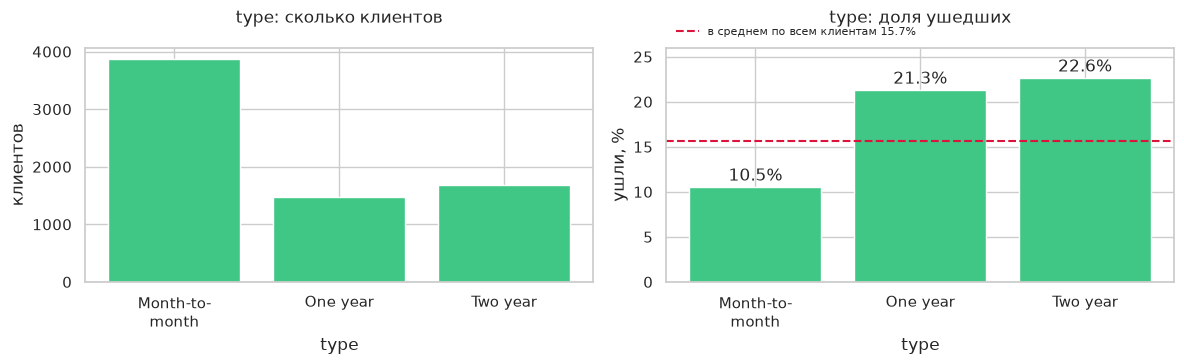

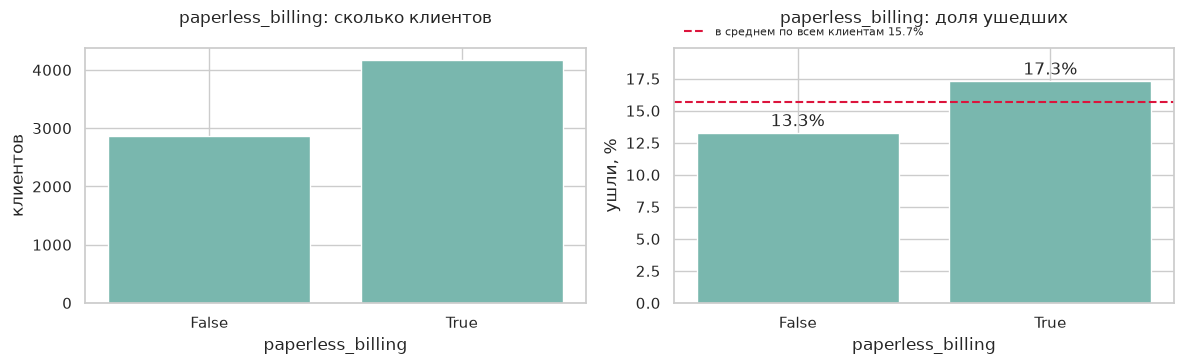

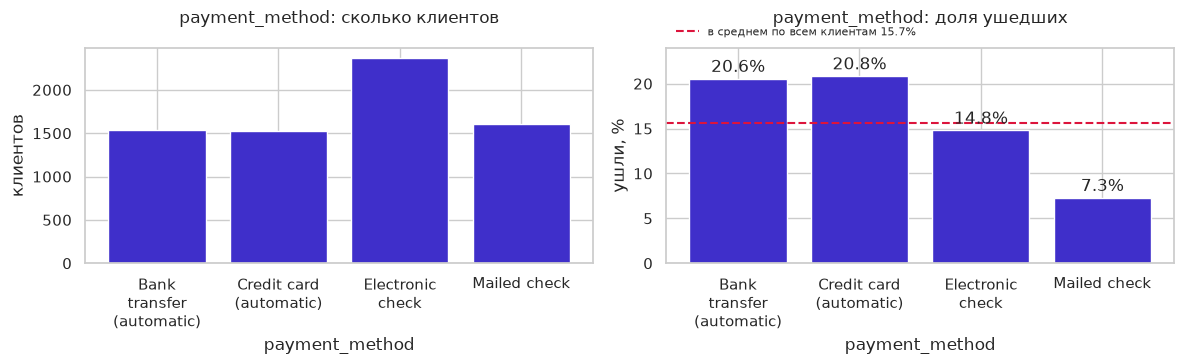

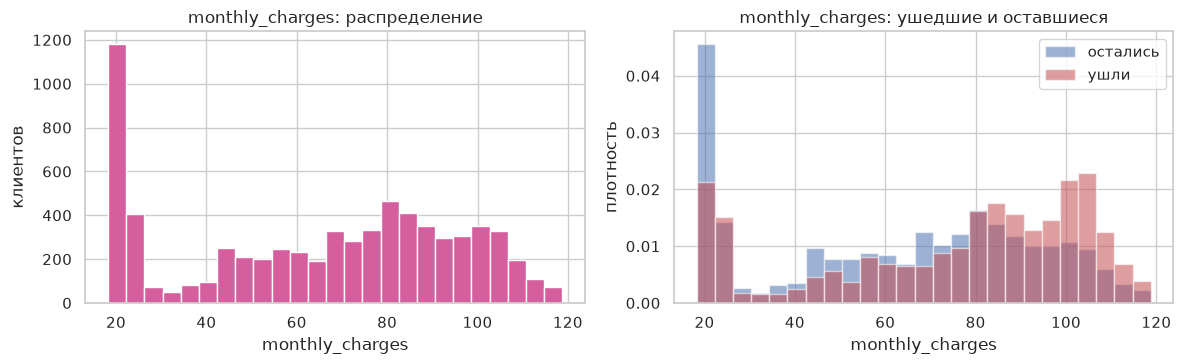

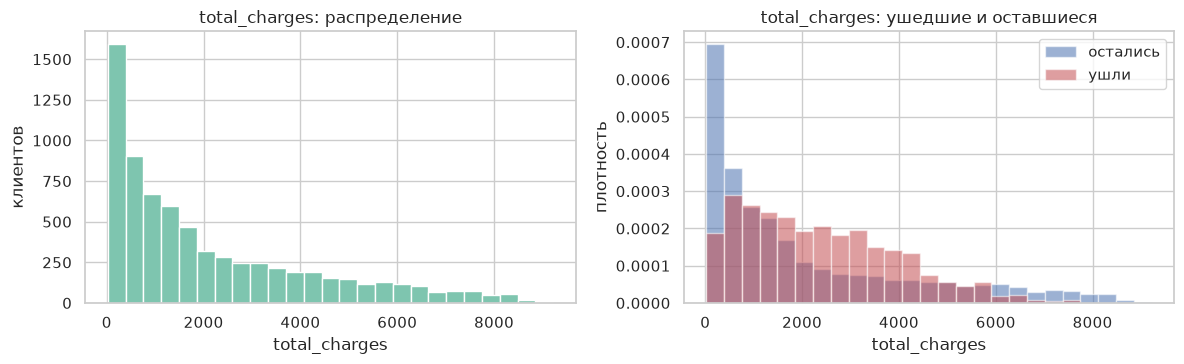

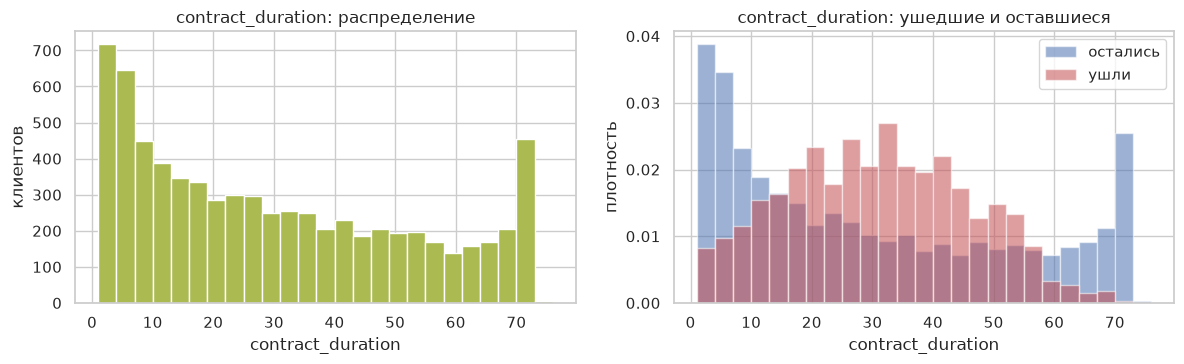

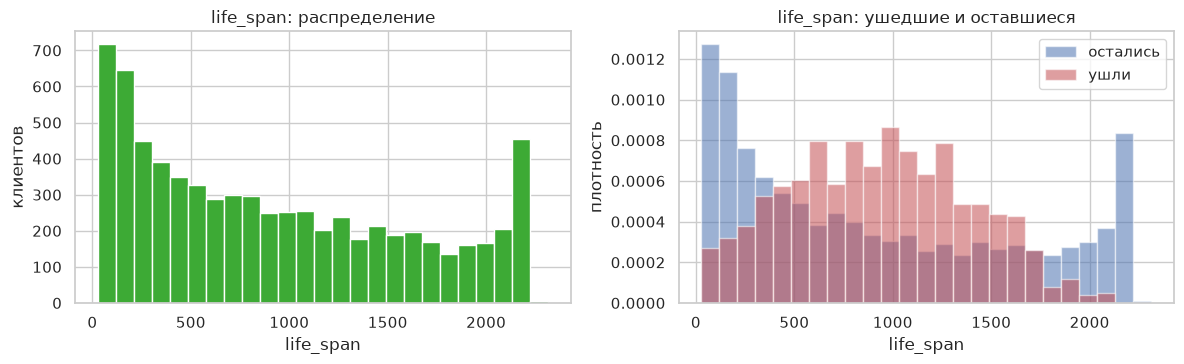

In [58]:
contract_features = ['type', 'paperless_billing', 'payment_method',
                     'monthly_charges', 'total_charges', 'contract_duration', 'life_span']

for feature in contract_features:
    plot_feature(feature)

**Распределения частот**

- **`type`:** больше половины базы на помесячном договоре, 55.1%, двухлетних 24.0%, годовых 20.9%
- **`paperless_billing`:** электронный расчётный лист у 59.3% клиентов, бумажный у 40.7%
- **`payment_method`:** лидирует электронный чек, 33.6%, остальные три способа почти равны, 21.6–22.8%
- **`monthly_charges`:** распределение бимодальное, узкий пик на 18–26 держит 22.6% клиентов, широкое плато 70–110 ещё 48.0%, медиана 70.35
- **`total_charges`:** сильно скошено вправо, медиана 1345 при среднем 2119, ниже 1000 сидят 42.0% клиентов, хвост тянется до 9221
- **`contract_duration`:** спад от левого края, 19.4% не дожили до 7 месяцев, со всплеском у правого, 6.6% на 70–76 месяцах, медиана 25
- **`life_span`:** та же форма в днях, медиана 761, разброс 28–2314, в 200 дней укладываются те же 19.4%

Делю каждый числовой признак на пять равных по числу клиентов групп и смотрю долю ушедших в каждой. Рядом медианный стаж группы

In [59]:
quintile_rows = []
for feature in continuous_features:
    grouped = data.groupby(pd.qcut(data[feature], 5), observed=True)
    quintile_rows.append(pd.DataFrame({
        'признак': feature,
        'клиентов': grouped['churn'].size(),
        'ушли, %': grouped['churn'].mean().mul(100).round(1),
        'медианный стаж, мес': grouped['contract_duration'].median(),
    }).rename_axis('интервал').reset_index())

pd.concat(quintile_rows).set_index(['признак', 'интервал'])

клиентов  ушли, %  медианный стаж, мес
признак           интервал                                                 
monthly_charges   (18.249, 25.05]        1416      9.8                 20.0
                  (25.05, 58.92]         1397     11.0                 18.0
                  (58.92, 79.15]         1415     12.7                 19.0
                  (79.15, 94.3]          1404     18.2                 26.0
                  (94.3, 118.75]         1400     26.7                 41.0
total_charges     (19.049, 335.004]      1407      4.7                  3.0
                  (335.004, 917.7]       1408     12.5                 11.0
                  (917.7, 1853.68]       1404     17.9                 23.0
                  (1853.68, 3848.2]      1406     29.2                 34.0
                  (3848.2, 9221.38]      1407     14.1                 61.0
contract_duration (0.999, 7.0]           1532      5.0                  4.0
                  (7.0, 18.0]            1350     14.3                 13.0
                  (18.0, 33.0]           1385     27.0                 26.0
                  (33.0, 53.0]           1406     27.2                 43.0
                  (53.0, 76.0]           1359      5.5                 66.0
life_span         (27.999, 215.0]        1532      5.0                  4.0
                  (215.0, 549.0]         1348     14.2                 13.0
                  (549.0, 1006.0]        1384     27.0                 26.0
                  (1006.0, 1614.0]       1409     27.4                 43.0
                  (1614.0, 2314.0]       1359      5.5                 66.0

Реже всех уходят клиенты на помесячном договоре и с бумажным чеком. Проверяю самое очевидное объяснение, разный стаж. Отток здесь означает "договор расторгнут когда-нибудь до 1 февраля 2020 года"

In [60]:
long_tenure = data[data['contract_duration'] > 24]

for feature in ['type', 'payment_method']:
    display(pd.DataFrame({
        'клиентов': data.groupby(feature)['churn'].size(),
        'медианный стаж, мес': data.groupby(feature)['contract_duration'].median(),
        'ушли, %': data.groupby(feature)['churn'].mean().mul(100).round(1),
        'ушли среди стажа > 24 мес, %': long_tenure.groupby(feature)['churn'].mean().mul(100).round(1),
    }))

,клиентов,"медианный стаж, мес","ушли, %","ушли среди стажа > 24 мес, %"
type,,,,
Month-to-month,3875,12.0,10.5,18.8
One year,1472,37.0,21.3,19.6
Two year,1685,55.0,22.6,19.9


,клиентов,"медианный стаж, мес","ушли, %","ушли среди стажа > 24 мес, %"
payment_method,,,,
Bank transfer (automatic),1542,39.0,20.6,21.5
Credit card (automatic),1521,37.0,20.8,19.8
Electronic check,2365,17.0,14.8,21.9
Mailed check,1604,14.0,7.3,10.7


Срез "дольше двух лет" слишком широкий. Разрезаю стаж на три полосы и смотрю долю ушедших в каждой клетке, рядом число клиентов

In [61]:
tenure_bands = pd.cut(data['contract_duration'], [0, 24, 48, 76],
                      labels=['1–24 мес', '25–48 мес', '49–76 мес'])

type_churn_share = pd.crosstab(data['type'], tenure_bands, values=data['churn'],
                               aggfunc='mean', margins=True, margins_name='все').mul(100).round(1)
type_client_count = pd.crosstab(data['type'], tenure_bands, margins=True, margins_name='все')

pd.concat({'ушли, %': type_churn_share, 'клиентов': type_client_count}, axis=1)

ушли, %                           клиентов            \
contract_duration 1–24 мес 25–48 мес 49–76 мес   все 1–24 мес 25–48 мес   
type                                                                      
Month-to-month         7.4      21.0      10.7  10.5     2819       832   
One year              25.5      27.6       9.2  21.3      411       602   
Two year              39.0      45.8       8.6  22.6      236       441   
все                   11.7      29.0       9.0  15.7     3466      1875   

                                   
contract_duration 49–76 мес   все  
type                               
Month-to-month          224  3875  
One year                459  1472  
Two year               1008  1685  
все                    1691  7032

**Что видно по договору и платежам**

- **Тип договора. В целом чаще уходят те, у кого договор длиннее** (10.5% у помесячных против 21.3% и 22.6%), но это эффект стажа. Внутри одинакового стажа картина обратная: при 1–24 месяцах ушли 7.4% помесячных против 39.0% двухлетних
- **Способ платежа. Бумажный чек резко выделяется,** 7.3% против 14.8–20.8% у остальных, и при одинаковом стаже он остаётся самой лояльной группой
- **Месячный платёж. Чем больше счёт, тем выше отток,** от 9.8% в нижнем квинтиле до 26.7% в верхнем
- **У накопленной суммы и обоих признаков срока связь немонотонная.** Реже всего уходят новички (5.0%) и старожилы (5.5%), максимум в середине шкалы 27%. Модели нужна не линия, а разбиение на интервалы, это работа для деревьев
- **Срок жизни в днях повторяет длительность в месяцах** до третьего знака

### 7.2 Персональные данные

Пенсионный статус и наличие супруга

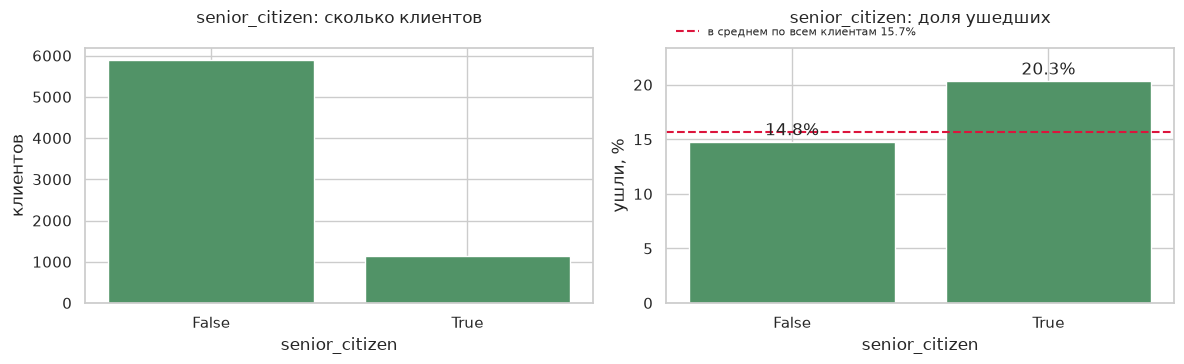

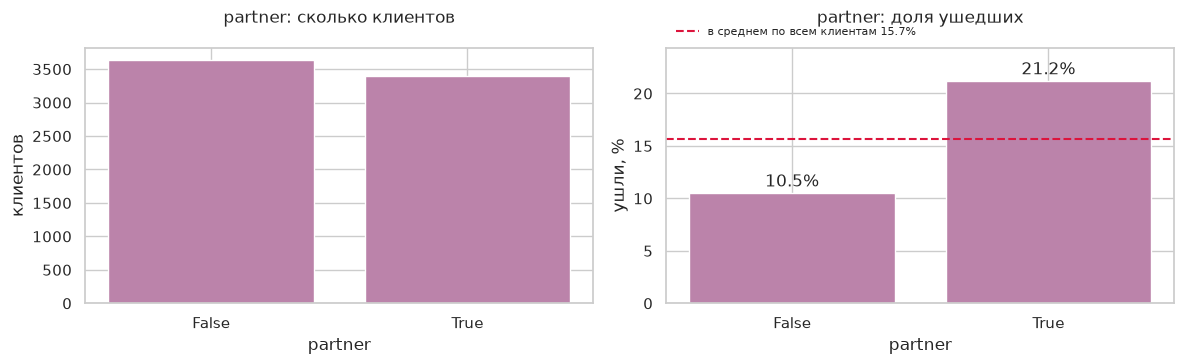

In [62]:
personal_features = ['senior_citizen', 'partner']

for feature in personal_features:
    plot_feature(feature)

**Что видно по персональным данным**

- **Пенсионеры уходят чаще** 20.3% против 14.8%
- **Наличие супруга самый сильный признак группы** 21.2% против 10.5%, причём направление обратное гипотезе про менее подвижного семейного клиента

### 7.3 Интернет и дополнительные услуги

Шесть сервисов, которые продаются вместе с интернетом

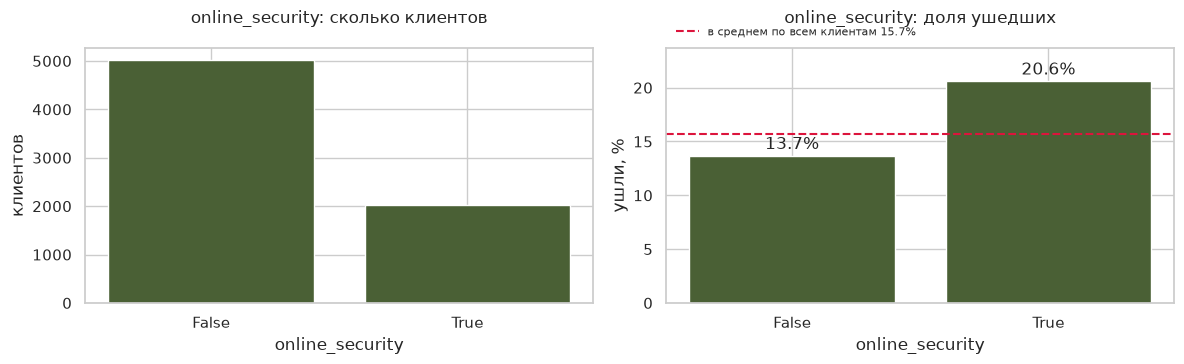

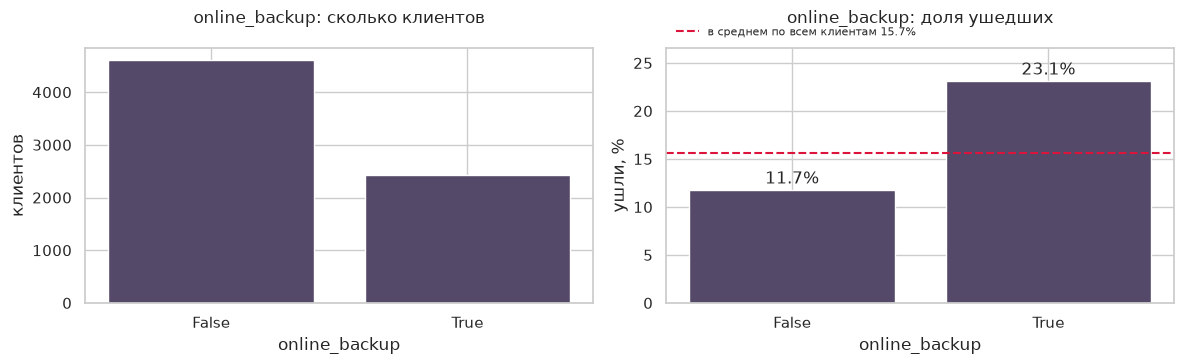

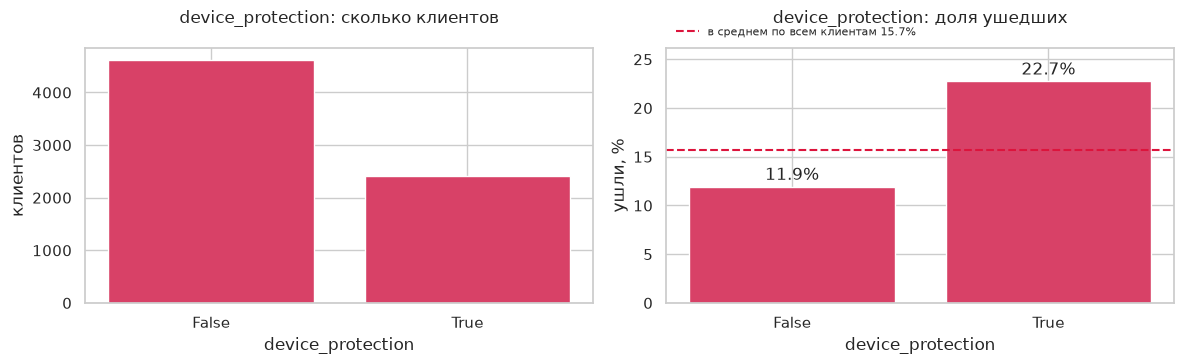

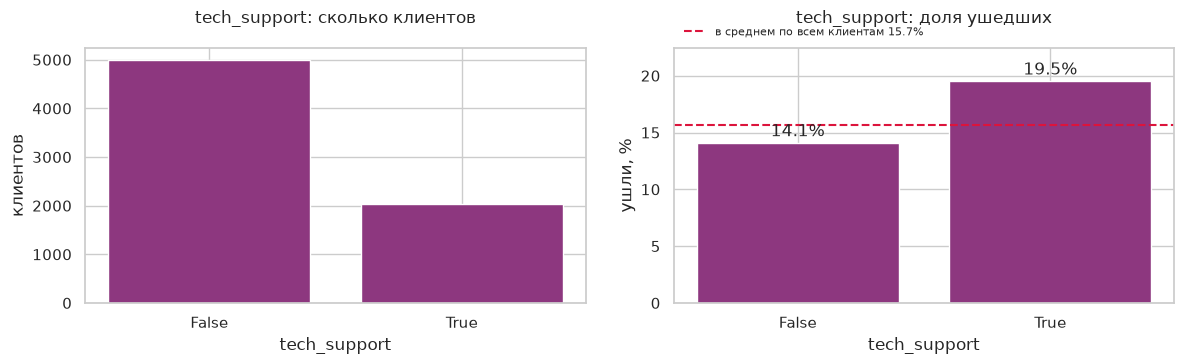

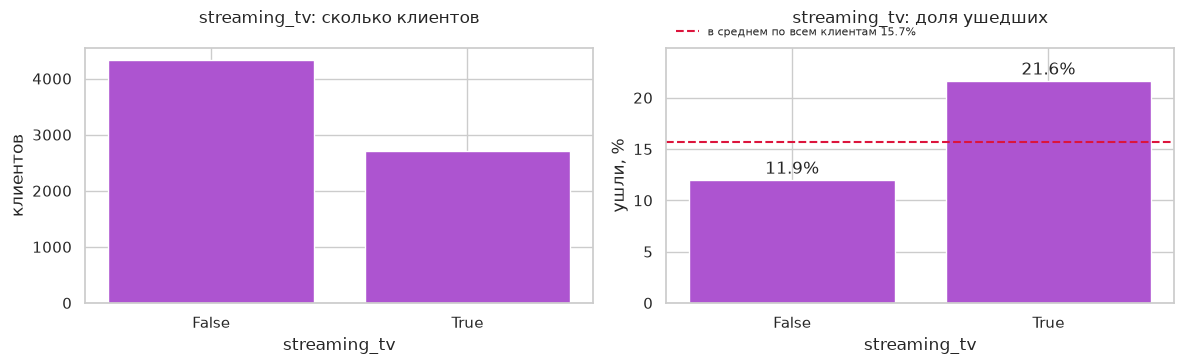

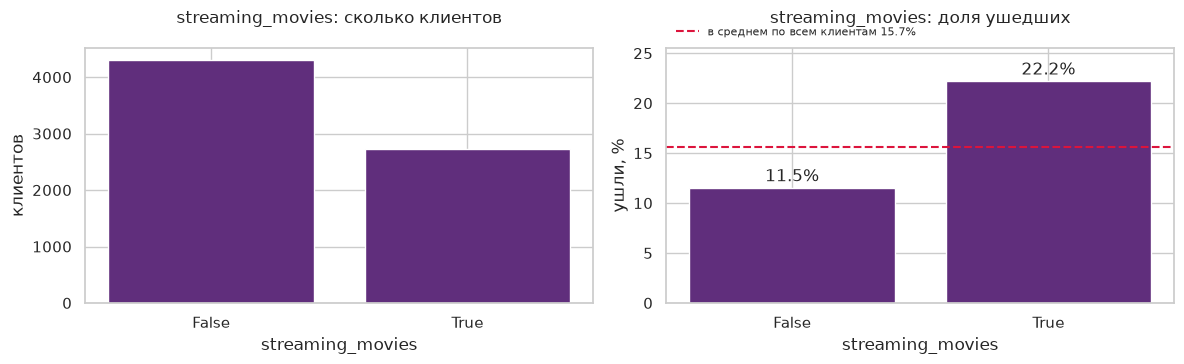

In [63]:
internet_features = ['online_security', 'online_backup', 'device_protection',
                     'tech_support', 'streaming_tv', 'streaming_movies']

for feature in internet_features:
    plot_feature(feature)

**Что видно по интернет-услугам**

- **Все шесть услуг ведут себя одинаково. Где услуга подключена, там отток выше,** от 19.5% до 23.1% против 11.5–14.1%. Гипотеза "чем больше сервисов, тем дороже переезжать" не подтвердилась, знак обратный

### 7.4 Телефония и новые признаки

Единственная услуга телефонии, счётчик услуг из начала раздела и флаг подключения к интернету

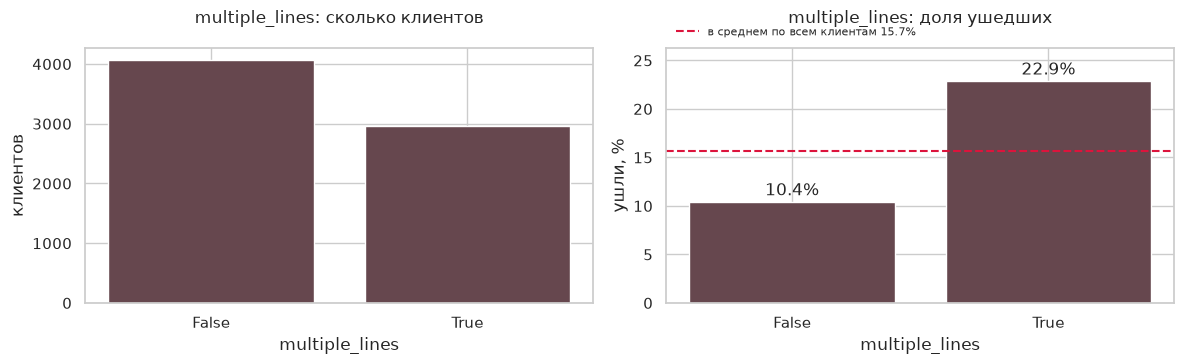

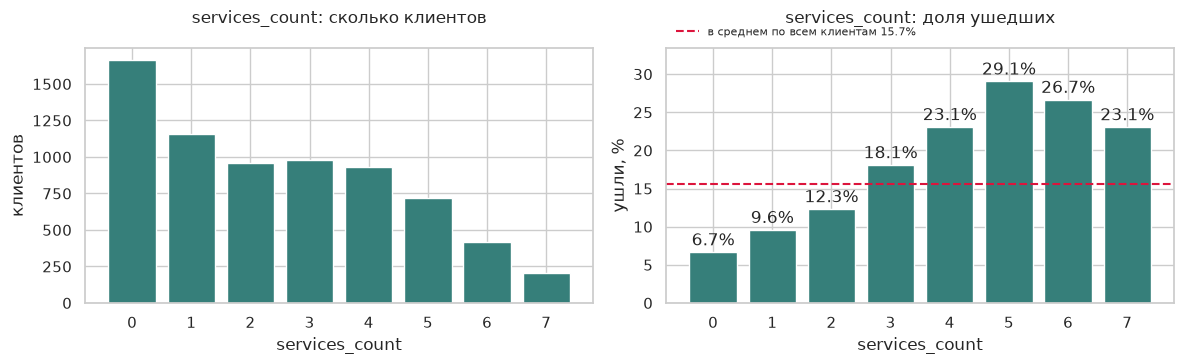

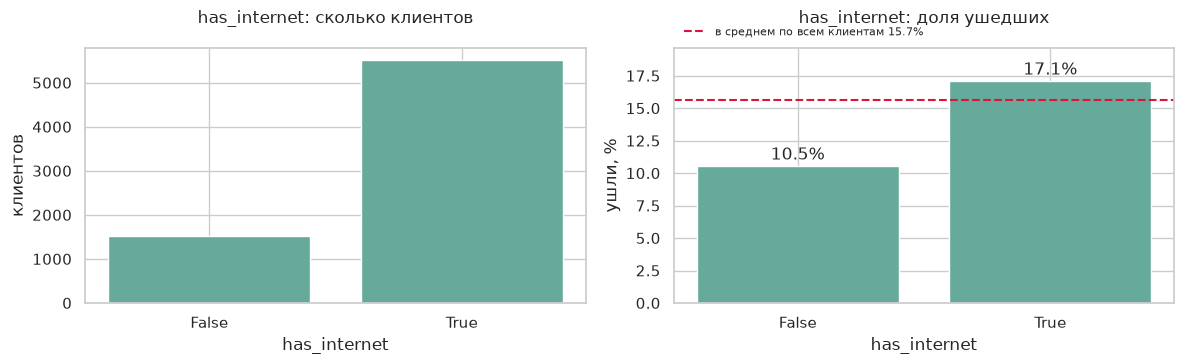

In [64]:
phone_and_new_features = ['multiple_lines', 'services_count', 'has_internet']

for feature in phone_and_new_features:
    plot_feature(feature)

Проверяю то же объяснение, что и в 7.1. Не стоит ли за числом услуг обычный стаж

In [65]:
pd.DataFrame({
    'клиентов': data.groupby('services_count')['churn'].size(),
    'медианный стаж, мес': data.groupby('services_count')['contract_duration'].median(),
    'ушли, %': data.groupby('services_count')['churn'].mean().mul(100).round(1),
})

,клиентов,"медианный стаж, мес","ушли, %"
services_count,,,
0,1663,12.0,6.7
1,1156,13.0,9.6
2,957,17.0,12.3
3,978,26.0,18.1
4,931,37.0,23.1
5,719,44.0,29.1
6,420,58.0,26.7
7,208,68.0,23.1


Беру ту же разрезку, сгруппировав число услуг попарно. Самые тонкие клетки оставляю. Процент на полусотне клиентов это тенденция, а не оценка

In [66]:
services_bands = pd.cut(data['services_count'], [-1, 1, 3, 5, 7], labels=['0–1', '2–3', '4–5', '6–7'])

services_churn_share = pd.crosstab(services_bands, tenure_bands, values=data['churn'],
                                   aggfunc='mean', margins=True, margins_name='все').mul(100).round(1)
services_client_count = pd.crosstab(services_bands, tenure_bands, margins=True, margins_name='все')

pd.concat({'ушли, %': services_churn_share, 'клиентов': services_client_count}, axis=1)

ушли, %                           клиентов            \
contract_duration 1–24 мес 25–48 мес 49–76 мес   все 1–24 мес 25–48 мес   
services_count                                                            
0–1                    4.9      18.7       7.7   7.9     1899       530   
2–3                   12.1      23.9       8.7  15.2     1082       590   
4–5                   32.7      36.1      10.3  25.7      431       610   
6–7                   74.1      57.2       8.6  25.5       54       145   
все                   11.7      29.0       9.0  15.7     3466      1875   

                                   
contract_duration 49–76 мес   все  
services_count                     
0–1                     390  2819  
2–3                     263  1935  
4–5                     609  1650  
6–7                     429   628  
все                    1691  7032

**Что видно по телефонии и новым признакам**

- **Несколько линий сильный разделитель** 22.9% против 10.4%
- **Счётчик услуг даёт самую широкую шкалу оттока** от 6.7% без единой услуги до 29.1% у подключивших пять
- **Число услуг сильно связано со стажем, но к нему не сводится.** Внутри полосы 1–24 месяца ушли 4.9% с нулём-одной услугой против 74.1% с шестью-семью. Разделить вклад стажа и набора услуг в EDA нельзя, это сделает модель. Утечки в счётчике нет

Свожу картину в таблицу. Минимальная и максимальная доля ушедших по категориям и размах между ними. Четыре числовых признака не беру, их разбор в квантилях 7.1

In [67]:
category_rates = {feature: data.groupby(feature)['churn'].mean().mul(100)
                  for feature in plotted_features if feature not in continuous_features}

churn_spread = pd.DataFrame([
    {'признак': feature, 'категорий': len(rates), 'минимум, %': rates.min(),
     'максимум, %': rates.max(), 'размах, п.п.': rates.max() - rates.min()}
    for feature, rates in category_rates.items()
]).set_index('признак').sort_values('размах, п.п.', ascending=False).round(1)

churn_spread

,категорий,"минимум, %","максимум, %","размах, п.п."
признак,,,,
services_count,8,6.7,29.1,22.4
payment_method,4,7.3,20.8,13.5
multiple_lines,2,10.4,22.9,12.4
type,3,10.5,22.6,12.1
online_backup,2,11.7,23.1,11.3
device_protection,2,11.9,22.7,10.8
partner,2,10.5,21.2,10.7
streaming_movies,2,11.5,22.2,10.7
streaming_tv,2,11.9,21.6,9.7


**Промежуточный вывод о выборе набора признаков для обучения**

- Ни один признак не делит клиентов пополам по оттоку. Лучший по размаху `services_count` 22.4%, дальше `payment_method` 13.5% и `multiple_lines` 12.4%. Качество даст сложение слабых сигналов
- Многие связи опосредованы стажем, но им не исчерпываются, вклад разделит модель
- У `contract_duration`, `life_span` и `total_charges` связь немонотонная, это аргумент за деревья

**Что беру в обучение.** Семнадцать признаков, явным списком они выписаны в разделе 8. Не беру `customer_id`, обе даты по запрету ТЗ, `contract_duration` (в `X` идёт ровно одна производная `begin_date`, и дневная шкала точнее месячной) и трёх кандидатов из 6.4, которые слабее своих источников. `gender`, `dependents` и `internet_service` отсеяны раньше, в 6.3

<div class="alert alert-success">
<h2> Комментарий ментора<a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Отлично, графики хорошо читаемы, выводы логичные, можно определить портрет уходящего клиента. Такая информация полезна для бизнеса

## 8. Подготовка выборок

Собираю матрицу из набора раздела 7, делю данные 75 на 25 со `stratify` и описываю преобразования. Тестовую выборку откладываю и до финальной проверки не трогаю

Делю признаки на три группы: два текстовых столбца закодировать, четыре числовых привести к одному масштабу, одиннадцать флагов уже `bool`. Флагу кодирование не нужно, one-hot развернул бы каждый в две зеркальные колонки, поэтому категориальных остаётся ровно два: `type` и `payment_method`

In [68]:
model_features = ['type', 'paperless_billing', 'payment_method', 'monthly_charges',
                  'total_charges', 'life_span', 'senior_citizen', 'partner',
                  'online_security', 'online_backup', 'device_protection', 'tech_support',
                  'streaming_tv', 'streaming_movies', 'multiple_lines', 'services_count',
                  'has_internet']

categorical_features = ['type', 'payment_method']
numeric_features = ['monthly_charges', 'total_charges', 'life_span', 'services_count']
binary_features = ['paperless_billing', 'senior_citizen', 'partner', 'online_security',
                   'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
                   'streaming_movies', 'multiple_lines', 'has_internet']

len(model_features)

17

Сверяю список с таблицей до того, как что-то из него строить: все семнадцать имён есть в `data`, запрещённых нет, производная от дат ровно одна и она названа поимённо, три группы покрывают список и не пересекаются

In [69]:
forbidden_features = ['customer_id', 'begin_date', 'end_date', 'contract_duration']
date_derived_suffixes = ('_age', '_days', '_months', '_year', '_month', '_since', '_until',
                        '_duration', '_span')
sanctioned_date_features = ['life_span']
date_derived = [column for column in data.columns
                if column.endswith(date_derived_suffixes)]
unsanctioned_date_derived = [column for column in date_derived
                             if column not in sanctioned_date_features]
grouped_features = categorical_features + numeric_features + binary_features

pd.Series({
    'признаков в списке': len(model_features),
    'нет в мастер-таблице': sorted(set(model_features) - set(data.columns)),
    'запрещённых в списке': sorted(set(forbidden_features) & set(model_features)),
    'производных от дат в списке': sorted(set(date_derived) & set(model_features)),
    'из них несогласованных': sorted(set(unsanctioned_date_derived) & set(model_features)),
    'группы покрывают список': set(grouped_features) == set(model_features),
    'признаков в двух группах': len(grouped_features) - len(set(grouped_features)),
}, name='значение').to_frame()

,значение
признаков в списке,17
нет в мастер-таблице,[]
запрещённых в списке,[]
производных от дат в списке,[life_span]
из них несогласованных,[]
группы покрывают список,True
признаков в двух группах,0


Собираю матрицу признаков и вектор ответов и делю на две выборки. `stratify` держит долю ушедших одинаковой, `random_state` делает разбиение воспроизводимым

In [70]:
X = data[model_features]
y = data['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

X_train.shape, X_test.shape

((5274, 17), (1758, 17))

Доли ушедших в обеих выборках должны совпасть с общими 15.7%

In [71]:
pd.DataFrame({
    'клиентов': [len(X_train), len(X_test), len(X)],
    'ушедших': [y_train.sum(), y_test.sum(), y.sum()],
    'ушли, %': [100 * y_train.mean(), 100 * y_test.mean(), 100 * y.mean()],
}, index=['train', 'test', 'вся выборка']).round(2)

,клиентов,ушедших,"ушли, %"
train,5274,826,15.66
test,1758,275,15.64
вся выборка,7032,1101,15.66


Два категориальных столбца кодирую one-hot, четыре числа привожу к одному масштабу ради нейросети, одиннадцать флагов пропускаю как есть. `drop=None` оставляет все категории: линейных моделей в проекте нет, а деревьям так удобнее. `handle_unknown='ignore'` страхует от незнакомой категории

In [72]:
preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None),
     categorical_features),
    ('numeric', StandardScaler(), numeric_features),
    ('binary', 'passthrough', binary_features),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

<div class="alert alert-warning">
    <h2> Комментарий ментора <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> На будущее - здесь не показательно, при обучении моделей на основе деревьев (простые деревья, лес, lgbm, catboost) для высококардинальных категориальных признаков (признаков с большим количеством уникальных значений) нежелательно использовать OHE. Для достижения хорошей точности в этом случае необходимо растить очень глубокое дерево, что достаточно ресурсозатратно. По этой причине такие деревья часто остаются недообученными и несбаланасированными. Вместо OHE для таких признаков лучше использовать порядковое кодирование (<a href = 'https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder'>OrdinalEncoder</a>), благодаря чему при обучении дерева за счет одного шага можно будет делить сразу все категории на два подмножетсва, что поможет не делать слишком много шагов для углубления.
    
    
У lgbm и catboost при этом даже есть специальные параметры, через которые можно указать перечень признаков, требующих кодирования (хотя дефолтно модели сами могут определить, какие из признаков являются категориальными, это не всегда работает надежно, поэтому во избежание недопонимания с моделью лучше вручную прописать нуждающиеся в кодировании признаки): categorical_feature и cat_features соответсвнно.

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>
Кардинальность здесь 3 и 4 категории, OHE добавляет 5 столбцов из 22, глубина деревьев от этого не страдает, поэтому OrdinalEncoder не вводил. Категории без кодирования в работе тоже участвуют: в 9.5 CatBoost берёт их через cat_features.
</div>

Смотрю, во что превращается таблица после кодирования. В моделях тот же `preprocessor` живёт внутри `Pipeline` и переобучается на каждом фолде, а тестовую выборку не видит

In [73]:
train_encoded_preview = preprocessor.fit_transform(X_train)
one_hot_encoder = preprocessor.named_transformers_['categorical']

display(pd.Series({feature: len(categories) for feature, categories
                   in zip(categorical_features, one_hot_encoder.categories_)},
                  name='категорий').to_frame().T)

display(pd.Series({
    'строк в train': train_encoded_preview.shape[0],
    'столбцов после преобразования': train_encoded_preview.shape[1],
    'из них one-hot': sum(len(categories) for categories in one_hot_encoder.categories_),
    'масштабированных чисел': len(numeric_features),
    'флагов без изменений': len(binary_features),
}, name='значение').to_frame())

train_encoded_preview.shape

,type,payment_method
категорий,3,4


,значение
строк в train,5274
столбцов после преобразования,22
из них one-hot,7
масштабированных чисел,4
флагов без изменений,11


(5274, 22)

**Промежуточный вывод по разделу**

- В `X` семнадцать столбцов, сверка прошла чисто: запрещённых имён нет, производная от дат одна и она названа явно
- Разбиение 75 на 25 со стратификацией: 5274 клиента в train и 1758 в test, доли ушедших 15.66% и 15.64%
- `ColumnTransformer` даёт на входе модели 22 признака вместо 17: `type` три категории плюс `payment_method` четыре, четыре числа и одиннадцать флагов
- Тест изолирован до финальной проверки

## 9. Обучение моделей

Обучаю решающее дерево, градиентный бустинг и нейросеть, каждую внутри пайплайна с препроцессором раздела 8: преобразования переобучаются на тренировочной части каждого блока и не подсматривают ни в отложенный блок, ни в тест. Гиперпараметры подбираю через `OptunaSearchCV` по ROC-AUC на кросс-валидации из пяти блоков, блоки у всех моделей одни и те же. Из бустингов беру `HistGradientBoostingClassifier` ради скорости и параметра `l2_regularization`, который регуляризует значения в листьях. От мультиколлинеарности это не лечит, поэтому важности признаков всё равно буду читать группами

Разбиение создаю один раз и передаю всем моделям. Кэш нужен потому, что каждый поиск считается минутами, перед сдачей папку удаляю и прогоняю ноутбук начисто. Смену сетки, данных или препроцессора кэш не замечает

In [74]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cache_dir = 'graduation_project/cache' if os.path.isdir('graduation_project') else 'cache'
os.makedirs(cache_dir, exist_ok=True)

cache_dir

'cache'

Выношу в функцию логику "посмотреть кэш, иначе запустить поиск и замерить время", рядом вторая сворачивает результат в табличку. Ставлю `n_jobs=-1`, все ядра машины

In [75]:
def run_search(name, estimator, param_distributions, n_trials, **fit_params):
    cache_path = os.path.join(cache_dir, f'{name}.joblib')
    if os.path.exists(cache_path):
        search, seconds = joblib.load(cache_path)
        return search, seconds, True

    search = OptunaSearchCV(estimator, param_distributions, cv=cv, scoring='roc_auc',
                            n_trials=n_trials, n_jobs=-1, random_state=RANDOM_STATE, verbose=0)
    started = time.perf_counter()
    search.fit(X_train, y_train, **fit_params)
    seconds = time.perf_counter() - started

    joblib.dump((search, seconds), cache_path)
    return search, seconds, False

In [76]:
def search_summary(search, seconds, from_cache):
    return pd.Series({
        'ROC-AUC на кросс-валидации': round(search.best_score_, 4),
        'попыток подбора': len(search.trials_),
        'время поиска, мин': round(seconds / 60, 1),
        'из кэша': 'да' if from_cache else 'нет',
        **{name.replace('model__', ''): value for name, value in search.best_params_.items()},
    }, name='значение').to_frame()

`DummyClassifier` со стратегией `prior` выдаёт всем одну и ту же вероятность ухода, поэтому его ROC-AUC ровно 0.5. Всё, что модели покажут выше этой черты, взято из признаков

In [77]:
baseline_pipeline = Pipeline([('preprocessing', preprocessor),
                              ('model', DummyClassifier(strategy='prior'))])

baseline_scores = cross_val_score(baseline_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

pd.Series({
    'ROC-AUC по блокам': ', '.join(f'{score:.3f}' for score in baseline_scores),
    'ROC-AUC в среднем': round(baseline_scores.mean(), 4),
}, name='значение').to_frame()

,значение
ROC-AUC по блокам,"0.500, 0.500, 0.500, 0.500, 0.500"
ROC-AUC в среднем,0.5


### 9.1 Решающее дерево

Одно дерево задаёт нижнюю границу качества для деревянных моделей. Подбираю `max_depth` от 2 до 12, `min_samples_leaf` от 3 до 100 по логарифмической шкале и `class_weight` в обоих вариантах

In [78]:
tree_pipeline = Pipeline([('preprocessing', preprocessor),
                          ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))])

tree_space = {
    'model__max_depth': IntDistribution(2, 12),
    'model__min_samples_leaf': IntDistribution(3, 100, log=True),
    'model__class_weight': CategoricalDistribution([None, 'balanced']),
}

tree_search, tree_seconds, tree_cached = run_search('decision_tree', tree_pipeline, tree_space, 40)

search_summary(tree_search, tree_seconds, tree_cached)

,значение
ROC-AUC на кросс-валидации,0.796
попыток подбора,40
"время поиска, мин",0.1
из кэша,да
max_depth,7
min_samples_leaf,88
class_weight,None


### 9.2 Градиентный бустинг

`HistGradientBoostingClassifier` строит деревья одно за другим, каждое исправляет ошибки предыдущих. Подбираю `learning_rate` от 0.01 до 0.2 и `max_iter` от 50 до 300 вместе, `max_leaf_nodes` от 15 до 63 и `l2_regularization` от 0.001 до 10

In [79]:
hist_pipeline = Pipeline([('preprocessing', preprocessor),
                          ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE))])

hist_space = {
    'model__learning_rate': FloatDistribution(0.01, 0.2, log=True),
    'model__max_iter': IntDistribution(50, 300),
    'model__max_leaf_nodes': IntDistribution(15, 63),
    'model__l2_regularization': FloatDistribution(1e-3, 10, log=True),
}

hist_search, hist_seconds, hist_cached = run_search('hist_boosting', hist_pipeline, hist_space, 40)

search_summary(hist_search, hist_seconds, hist_cached)

,значение
ROC-AUC на кросс-валидации,0.8934
попыток подбора,40
"время поиска, мин",3.3
из кэша,да
learning_rate,0.167112
max_iter,278
max_leaf_nodes,32
l2_regularization,7.891045


### 9.3 Нейросеть

`MLPClassifier`, ему важен масштаб признаков. Фиксирую `adam`, `relu`, батч из 64, потолок в 500 эпох и раннюю остановку. Перебираю пять архитектур от 16 нейронов до двух слоёв по 64 и 32, `alpha` от 0.00001 до 0.1 и `learning_rate_init` от 0.0001 до 0.005, попыток 30

In [80]:
mlp_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', MLPClassifier(solver='adam', activation='relu', batch_size=64, max_iter=500,
                            early_stopping=True, validation_fraction=0.15, n_iter_no_change=15,
                            random_state=RANDOM_STATE)),
])

mlp_space = {
    'model__hidden_layer_sizes': CategoricalDistribution([(16,), (32,), (64,), (32, 16), (64, 32)]),
    'model__alpha': FloatDistribution(1e-5, 1e-1, log=True),
    'model__learning_rate_init': FloatDistribution(1e-4, 5e-3, log=True),
}

mlp_search, mlp_seconds, mlp_cached = run_search('mlp', mlp_pipeline, mlp_space, 30)

search_summary(mlp_search, mlp_seconds, mlp_cached)

,значение
ROC-AUC на кросс-валидации,0.827
попыток подбора,30
"время поиска, мин",2.2
из кэша,да
hidden_layer_sizes,"(64,)"
alpha,0.000017
learning_rate_init,0.000905


### 9.4 Расширенный поиск

Компактный перебор дал 0.8934 у `HistGB`. Раздвигаю диапазоны, добавляю параметры и увеличиваю число попыток, кросс-валидация та же — проверяю, дожимают ли широкие сетки

У дерева добавляю `criterion`, `max_features` и `ccp_alpha`, поднимаю потолок глубины до 18 и размер листа до 150. Попыток 80

In [81]:
wide_tree_space = {
    'model__criterion': CategoricalDistribution(['gini', 'log_loss']),
    'model__max_depth': IntDistribution(2, 18),
    'model__min_samples_leaf': IntDistribution(2, 150, log=True),
    'model__max_features': FloatDistribution(0.5, 1.0),
    'model__ccp_alpha': FloatDistribution(1e-7, 2e-2, log=True),
    'model__class_weight': CategoricalDistribution([None, 'balanced']),
}

wide_tree_search, wide_tree_seconds, wide_tree_cached = run_search(
    'decision_tree_wide', tree_pipeline, wide_tree_space, 80)

search_summary(wide_tree_search, wide_tree_seconds, wide_tree_cached)

,значение
ROC-AUC на кросс-валидации,0.7969
попыток подбора,80
"время поиска, мин",0.1
из кэша,да
criterion,gini
max_depth,8
min_samples_leaf,106
max_features,0.934594
ccp_alpha,0.00008
class_weight,None


Классический `GradientBoostingClassifier` сопротивляется переобучению независимо от `l2_regularization`: `subsample` учит каждое дерево на случайной части клиентов, `max_features` на случайной части признаков. Деревьев от 150 до 700 при глубине от 1 до 4, ранняя остановка, попыток 90

In [82]:
gb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', GradientBoostingClassifier(n_iter_no_change=15, validation_fraction=0.12,
                                         random_state=RANDOM_STATE)),
])

gb_space = {
    'model__n_estimators': IntDistribution(150, 700, step=25),
    'model__learning_rate': FloatDistribution(0.008, 0.2, log=True),
    'model__max_depth': IntDistribution(1, 4),
    'model__min_samples_leaf': IntDistribution(5, 80, log=True),
    'model__subsample': FloatDistribution(0.6, 1.0),
    'model__max_features': FloatDistribution(0.6, 1.0),
}

gb_search, gb_seconds, gb_cached = run_search('gradient_boosting', gb_pipeline, gb_space, 90)

search_summary(gb_search, gb_seconds, gb_cached)

,значение
ROC-AUC на кросс-валидации,0.8543
попыток подбора,90
"время поиска, мин",1.8
из кэша,да
n_estimators,175
learning_rate,0.110348
max_depth,3
min_samples_leaf,7
subsample,0.903685
max_features,0.981062


У нейросети добавляю `tanh` и `batch_size` от 32 до 256, раздвигаю `alpha` и начальный шаг на порядок, к архитектурам добавляю 128 и пару 128 с 64. Попыток 90

In [83]:
wide_mlp_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', MLPClassifier(solver='adam', max_iter=500, early_stopping=True,
                            validation_fraction=0.15, n_iter_no_change=15,
                            random_state=RANDOM_STATE)),
])

wide_mlp_space = {
    'model__hidden_layer_sizes': CategoricalDistribution(
        [(16,), (32,), (64,), (128,), (32, 16), (64, 32), (128, 64)]),
    'model__activation': CategoricalDistribution(['relu', 'tanh']),
    'model__batch_size': CategoricalDistribution([32, 64, 128, 256]),
    'model__alpha': FloatDistribution(1e-6, 1e-1, log=True),
    'model__learning_rate_init': FloatDistribution(5e-5, 1e-2, log=True),
}

wide_mlp_search, wide_mlp_seconds, wide_mlp_cached = run_search(
    'mlp_wide', wide_mlp_pipeline, wide_mlp_space, 90)

search_summary(wide_mlp_search, wide_mlp_seconds, wide_mlp_cached)

,значение
ROC-AUC на кросс-валидации,0.8283
попыток подбора,90
"время поиска, мин",7.3
из кэша,да
hidden_layer_sizes,"(64,)"
activation,relu
batch_size,32
alpha,0.000099
learning_rate_init,0.006063


### 9.5 CatBoost с нативными категориями

Шесть поисков дали от 0.7960 до 0.8934. Проверяю объяснение, что дело не в моделях, а в one-hot-кодировании категорий: `CatBoost` строит разбиения по категориям напрямую и препроцессор ему не нужен. Подбираю `iterations` от 300 до 1500, `depth` от 3 до 6, `learning_rate` от 0.01 до 0.2 и `l2_leaf_reg` от 1 до 30, попыток 35. Сюда же кладу `auto_class_weights`: классы 15.7 против 84.3, пусть подбор сам решит, нужен ли вес редкому классу

In [84]:
catboost_model = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0,
                                    allow_writing_files=False)

catboost_space = {
    'iterations': IntDistribution(300, 1500),
    'depth': IntDistribution(3, 6),
    'learning_rate': FloatDistribution(0.01, 0.2, log=True),
    'l2_leaf_reg': FloatDistribution(1, 30, log=True),
    'auto_class_weights': CategoricalDistribution(['None', 'Balanced']),
}

catboost_search, catboost_seconds, catboost_cached = run_search(
    'catboost', catboost_model, catboost_space, 35, cat_features=categorical_features)

search_summary(catboost_search, catboost_seconds, catboost_cached)

,значение
ROC-AUC на кросс-валидации,0.9219
попыток подбора,35
"время поиска, мин",1.6
из кэша,да
iterations,1449
depth,3
learning_rate,0.095905
l2_leaf_reg,1.024963
auto_class_weights,None


**Что дал CatBoost**

0.9219 против 0.8934 у лучшего поиска на one-hot, разница +0.0285, что согласуется с гипотезой про кодирование категорий, хотя сравниваются разные семейства моделей. Вес редкого класса подбор не взял, `auto_class_weights` остался 'None': выравнивание классов кросс-валидацию не улучшило. Порог ТЗ 0.85 превышен уже на кросс-валидации, запас 0.0719

### 9.6 Ансамбль

Семейства разошлись сильно, от 0.7960 до 0.9219, так что усреднять их ради снятия шума нет смысла. Проверяю другое: каждое семейство собирает размазанный сигнал по-своему и ошибается на разных клиентах, поэтому ансамбль беру как страховку от того, что одиночный лидер подстроился под кросс-валидацию

Складываю не вероятности, а ранги, потому что вероятности откалиброваны по-разному, а ROC-AUC смотрит только на порядок. Шкалу замораживаю на обучении, иначе оценка клиента зависела бы от того, с кем он приехал в одном файле

`fit` обучает каждую базовую модель дважды: по блокам ради прогнозов на невиданных данных для замороженной шкалы и на всей обучающей части. `predict_proba` переводит прогноз в ранг через `np.searchsorted` и усредняет три ранга

In [85]:
class RankAverageEnsemble(ClassifierMixin, BaseEstimator):
    def __init__(self, models, cv):
        self.models = models
        self.cv = cv

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.fitted_models_ = []
        self.score_grids_ = []
        for model, fit_kwargs in self.models:
            out_of_fold = cross_val_predict(model, X, y, cv=self.cv, method='predict_proba',
                                            params=fit_kwargs)[:, 1]
            self.score_grids_.append(np.sort(out_of_fold))
            self.fitted_models_.append(clone(model).fit(X, y, **fit_kwargs))
        return self

    def predict_proba(self, X):
        ranks = [np.searchsorted(grid, model.predict_proba(X)[:, 1]) / len(grid)
                 for grid, model in zip(self.score_grids_, self.fitted_models_)]
        churn_score = np.mean(ranks, axis=0)
        return np.column_stack([1 - churn_score, churn_score])

В ансамбль беру лучших представителей трёх семейств: CatBoost на нативных категориях, градиентный бустинг на one-hot и нейросеть из 9.4. `clone` отдаёт модель с теми же параметрами, но необученную

In [86]:
ensemble_models = [
    (clone(catboost_search.best_estimator_), {'cat_features': categorical_features}),
    (clone(gb_search.best_estimator_), {}),
    (clone(wide_mlp_search.best_estimator_), {}),
]

rank_ensemble = RankAverageEnsemble(ensemble_models, cv)

pd.Series({'CatBoost, нативные категории': catboost_search.best_score_,
           'GradientBoosting, широкий поиск': gb_search.best_score_,
           'нейросеть, широкий поиск': wide_mlp_search.best_score_},
          name='CV ROC-AUC').round(4).to_frame()

,CV ROC-AUC
"CatBoost, нативные категории",0.9219
"GradientBoosting, широкий поиск",0.8543
"нейросеть, широкий поиск",0.8283


Оцениваю ансамбль той же кросс-валидацией. Внутри каждого блока обёртка строит шкалу заново, поэтому отложенный блок она видит впервые

In [87]:
ensemble_cache_path = os.path.join(cache_dir, 'rank_average_ensemble.joblib')

if os.path.exists(ensemble_cache_path):
    ensemble_scores, ensemble_seconds = joblib.load(ensemble_cache_path)
else:
    started = time.perf_counter()
    ensemble_scores = cross_val_score(rank_ensemble, X_train, y_train, cv=cv,
                                      scoring='roc_auc', n_jobs=-1)
    ensemble_seconds = time.perf_counter() - started
    joblib.dump((ensemble_scores, ensemble_seconds), ensemble_cache_path)

pd.Series({
    'ROC-AUC по блокам': ', '.join(f'{score:.3f}' for score in ensemble_scores),
    'ROC-AUC в среднем': round(ensemble_scores.mean(), 4),
    'время оценки, мин': round(ensemble_seconds / 60, 1),
}, name='значение').to_frame()

,значение
ROC-AUC по блокам,"0.874, 0.886, 0.887, 0.882, 0.880"
ROC-AUC в среднем,0.8819
"время оценки, мин",0.4


Проверяю главное свойство конструкции. Оценка клиента не должна зависеть от того, кто приехал вместе с ним

In [88]:
rank_ensemble.fit(X_train, y_train)

whole_batch = rank_ensemble.predict_proba(X_train)[:, 1]
small_batch = rank_ensemble.predict_proba(X_train.head(25))[:, 1]
single_client = rank_ensemble.predict_proba(X_train.head(1))[:, 1]

pd.Series({
    'клиентов в проверке': len(X_train),
    'пачка из 25 дала те же оценки': bool(np.allclose(whole_batch[:25], small_batch)),
    'один клиент дал ту же оценку': bool(np.allclose(whole_batch[:1], single_client)),
}, name='значение').to_frame()

,значение
клиентов в проверке,5274
пачка из 25 дала те же оценки,True
один клиент дал ту же оценку,True


**Что дал ансамбль**

0.8819, ниже лучшей одиночной модели на 0.0400 при разбросе между блоками 0.013. Страховка не понадобилась. `CatBoost` ушёл далеко вперёд, а усреднение рангов с более слабыми семействами тянет его вниз. Это нормальный исход проверки, а не поломка. Свойство, ради которого шкала замораживалась, подтвердилось. Оценка клиента совпадает на пачках от одного клиента до всей выборки

Свожу в таблицу семь поисков, бейзлайн и ансамбль с временем подбора и лучшими параметрами

In [89]:
searches = {'дерево, компактный поиск': (tree_search, tree_seconds),
            'HistGB, компактный поиск': (hist_search, hist_seconds),
            'нейросеть, компактный поиск': (mlp_search, mlp_seconds),
            'дерево, широкий поиск': (wide_tree_search, wide_tree_seconds),
            'GradientBoosting, широкий поиск': (gb_search, gb_seconds),
            'нейросеть, широкий поиск': (wide_mlp_search, wide_mlp_seconds),
            'CatBoost, нативные категории': (catboost_search, catboost_seconds)}

leaderboard_rows = [{'модель': 'бейзлайн DummyClassifier', 'CV ROC-AUC': baseline_scores.mean(),
                     'время поиска, мин': 0.0, 'лучшие параметры': 'подбирать нечего'}]

for name, (search, seconds) in searches.items():
    best_params = {key.replace('model__', ''): f'{value:.3g}' if isinstance(value, float) else value
                   for key, value in search.best_params_.items()}
    leaderboard_rows.append({'модель': name, 'CV ROC-AUC': search.best_score_,
                             'время поиска, мин': round(seconds / 60, 1),
                             'лучшие параметры': ', '.join(f'{key}={value}'
                                                           for key, value in best_params.items())})

leaderboard_rows.append({'модель': 'ансамбль рангов трёх семейств',
                         'CV ROC-AUC': ensemble_scores.mean(),
                         'время поиска, мин': round(ensemble_seconds / 60, 1),
                         'лучшие параметры': 'подбирать нечего, веса равные'})

leaderboard = pd.DataFrame(leaderboard_rows).set_index('модель').sort_values(
    'CV ROC-AUC', ascending=False).round(4)

leaderboard

,CV ROC-AUC,"время поиска, мин",лучшие параметры
модель,,,
"CatBoost, нативные категории",0.9219,1.6,"iterations=1449, depth=3, learning_rate=0.0959..."
"HistGB, компактный поиск",0.8934,3.3,"learning_rate=0.167, max_iter=278, max_leaf_no..."
ансамбль рангов трёх семейств,0.8819,0.4,"подбирать нечего, веса равные"
"GradientBoosting, широкий поиск",0.8543,1.8,"n_estimators=175, learning_rate=0.11, max_dept..."
"нейросеть, широкий поиск",0.8283,7.3,"hidden_layer_sizes=(64,), activation=relu, bat..."
"нейросеть, компактный поиск",0.8270,2.2,"hidden_layer_sizes=(64,), alpha=1.72e-05, lear..."
"дерево, широкий поиск",0.7969,0.1,"criterion=gini, max_depth=8, min_samples_leaf=..."
"дерево, компактный поиск",0.7960,0.1,"max_depth=7, min_samples_leaf=88, class_weight..."
бейзлайн DummyClassifier,0.5000,0.0,подбирать нечего


`n_estimators` у градиентного бустинга мог оказаться потолком, а не фактом. Ранняя остановка у модели включена. Смотрю фактическое число деревьев

In [90]:
best_gradient_boosting = gb_search.best_estimator_.named_steps['model']

pd.Series({
    'потолок n_estimators': best_gradient_boosting.n_estimators,
    'деревьев обучено фактически': int(best_gradient_boosting.n_estimators_),
    'ранняя остановка сработала': bool(best_gradient_boosting.n_estimators_
                                       < best_gradient_boosting.n_estimators),
}, name='значение').to_frame()

,значение
потолок n_estimators,175
деревьев обучено фактически,175
ранняя остановка сработала,False


Фиксирую лучшую одиночную модель. Какую конфигурацию вести на тест, решаю в конце раздела, до того как открою тестовую выборку

In [91]:
best_model_name = max(searches, key=lambda name: searches[name][0].best_score_)
best_search = searches[best_model_name][0]
best_cv_score = max(best_search.best_score_, ensemble_scores.mean())

pd.Series({
    'лучшая одиночная модель': best_model_name,
    'её ROC-AUC на кросс-валидации': round(best_search.best_score_, 4),
    'ансамбль рангов, ROC-AUC': round(ensemble_scores.mean(), 4),
    'лучший результат выше бейзлайна на': round(best_cv_score - baseline_scores.mean(), 4),
    'порог 0.85 на кросс-валидации': 'пройден' if best_cv_score >= 0.85 else 'не пройден',
}, name='значение').to_frame()

,значение
лучшая одиночная модель,"CatBoost, нативные категории"
её ROC-AUC на кросс-валидации,0.9219
"ансамбль рангов, ROC-AUC",0.8819
лучший результат выше бейзлайна на,0.4219
порог 0.85 на кросс-валидации,пройден


<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> хорошо, подроный и правильный пукнт моделирования, плюс за исследование разной обработки признаков для бустинга, понятный вывод результатов

### 9.7 На что опирается лучшая модель

Разбираю на обучающей выборке, на что опирается лучшая модель, тестовые строки для этого не нужны

Считаю вклады через SHAP. Он раскладывает каждый прогноз в сумму вкладов и для деревьев считает точно. Коррелированным признакам вклад достаётся произвольно, поэтому читаю группы, а не строчки рейтинга

Беру модель, уже переобученную на всей обучающей выборке, и считаю вклады для тех же 5274 клиентов

In [92]:
best_catboost = catboost_search.best_estimator_
train_pool = Pool(X_train, y_train, cat_features=categorical_features)
shap_values = shap.TreeExplainer(best_catboost).shap_values(train_pool)

shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train.columns,
                            name='средний |вклад|, лог-шансы').sort_values(ascending=False)

display(shap_importance.round(4).to_frame())

shap_values.shape

,"средний |вклад|, лог-шансы"
life_span,1.4250
total_charges,0.9415
type,0.6341
partner,0.3857
monthly_charges,0.3394
multiple_lines,0.2443
payment_method,0.2350
services_count,0.2062
paperless_billing,0.1335
online_backup,0.1198


(5274, 17)

Длина полосы это средний по клиентам модуль вклада в шансы ухода, подписи это доли в сумме вкладов

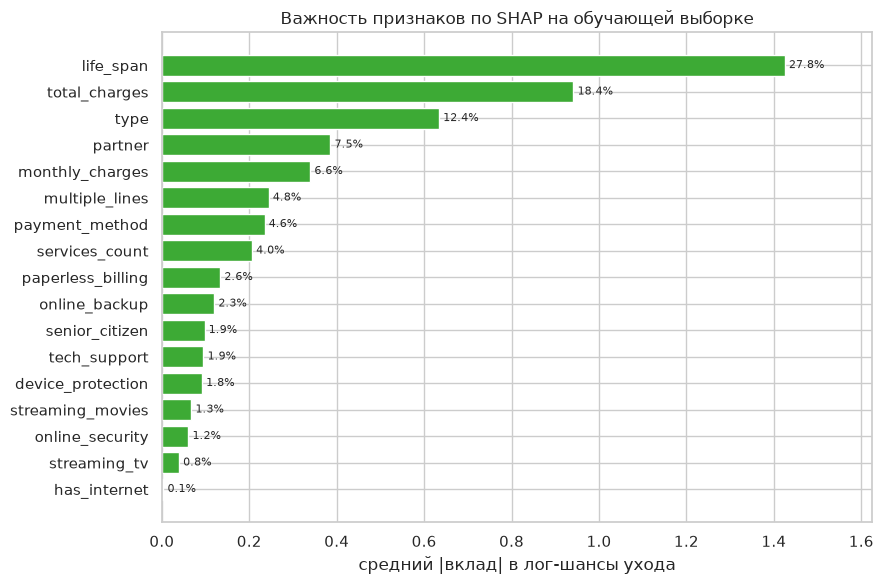

In [93]:
shap_share = 100 * shap_importance / shap_importance.sum()

fig, ax = plt.subplots(figsize=(9, 6))
importance_bars = ax.barh(shap_importance.index[::-1], shap_importance.to_numpy()[::-1],
                          color=feature_colors['life_span'])
ax.bar_label(importance_bars, labels=[f'{share:.1f}%' for share in shap_share[::-1]],
             padding=3, fontsize=8)
ax.margins(x=0.14)
ax.set(xlabel='средний |вклад| в лог-шансы ухода',
       title='Важность признаков по SHAP на обучающей выборке')
plt.tight_layout()
plt.show()

Складываю вклады по четырём блокам: деньги и стаж, условия договора и оплата, состав услуг, персональные данные

In [94]:
feature_groups = {
    'деньги и стаж': ['monthly_charges', 'total_charges', 'life_span'],
    'договор и оплата': ['type', 'paperless_billing', 'payment_method'],
    'услуги': ['online_security', 'online_backup', 'device_protection', 'tech_support',
               'streaming_tv', 'streaming_movies', 'multiple_lines', 'services_count',
               'has_internet'],
    'персональные данные': ['senior_citizen', 'partner'],
}

group_importance = pd.DataFrame([
    {'группа': group, 'признаков': len(features),
     'сумма |вклада|': shap_importance[features].sum(),
     'доля вклада, %': 100 * shap_importance[features].sum() / shap_importance.sum()}
    for group, features in feature_groups.items()
]).set_index('группа').sort_values('доля вклада, %', ascending=False).round(3)

display(group_importance)

sum(len(features) for features in feature_groups.values())

,признаков,сумма |вклада|,"доля вклада, %"
группа,,,
деньги и стаж,3,2.706,52.849
договор и оплата,3,1.003,19.582
услуги,9,0.928,18.129
персональные данные,2,0.483,9.440


17

**Что показал SHAP**

- Ни один признак не тянет прогноз на себе. Лидер `life_span` с 27.8%, три сильнейших дают 58.6%
- По группам вклад разложился так: деньги и стаж 52.8%, услуги 18.1% на девять признаков, договор и оплата 19.6%, персональные данные 9.4%
- Рейтинг читать по строкам нельзя: у `total_charges` с `life_span` phik 0.848, и при равном сигнале вклад забирает тот, кто первым попал в разрез
- Строить удержание на семейном положении абонента (`partner`, 7.5%) это решение этическое, и принимать его должен заказчик

### 9.8 Выбор финальной модели

Правило фиксирую до того, как начну тест. Финальной идёт одиночная модель, лучшая по CV ROC-AUC. Ансамбль забирает её место только если он опережает лучшую одиночную не меньше чем на 0.003, то есть заметнее, чем разброс между прогонами. Иначе одиночная, она проще и объяснимее

In [95]:
ensemble_model_name = 'ансамбль рангов трёх семейств'
single_cv_score = best_search.best_score_
ensemble_cv_score = ensemble_scores.mean()
ensemble_wins = ensemble_cv_score >= single_cv_score + 0.003

final_model_name = ensemble_model_name if ensemble_wins else best_model_name
final_estimator = clone(rank_ensemble if ensemble_wins else best_search.best_estimator_)
final_fit_kwargs = ({'cat_features': categorical_features}
                    if isinstance(final_estimator, CatBoostClassifier) else {})
final_cv_score = ensemble_cv_score if ensemble_wins else single_cv_score

pd.Series({
    'лучшая одиночная модель': best_model_name,
    'CV лучшей одиночной': round(single_cv_score, 4),
    'CV ансамбля рангов': round(ensemble_cv_score, 4),
    'преимущество ансамбля': round(ensemble_cv_score - single_cv_score, 4),
    'порог в пользу ансамбля': 0.003,
    'финальная модель': final_model_name,
    'CV финальной модели': round(final_cv_score, 4),
    'порог ТЗ 0.85 на кросс-валидации': 'пройден' if final_cv_score >= 0.85 else 'не пройден',
}, name='значение', dtype=object).to_frame()

,значение
лучшая одиночная модель,"CatBoost, нативные категории"
CV лучшей одиночной,0.9219
CV ансамбля рангов,0.8819
преимущество ансамбля,-0.04
порог в пользу ансамбля,0.003
финальная модель,"CatBoost, нативные категории"
CV финальной модели,0.9219
порог ТЗ 0.85 на кросс-валидации,пройден


**Промежуточный вывод по разделу**

- Бейзлайн дал 0.500 на каждом из пяти блоков
- Семь поисков уложились в коридор от 0.7960 до 0.9219: компактная волна дала 0.8934 у `HistGB`, широкая не дожала, её потолок 0.8543 у `GradientBoosting`
- `CatBoost` на нативных категориях дал 0.9219, вес редкого класса подбору не понадобился
- Ансамбль рангов трёх семейств дал 0.8819 и проиграл одиночному лидеру 0.0400
- Финальной становится CatBoost, CV ROC-AUC 0.9219. Порог ТЗ 0.85 на кросс-валидации пройден с запасом 0.0719
- Optuna работает во все ядра и порядок попыток не повторяется, поэтому третий знак может гулять: сравнивать модели имеет смысл только внутри одного прогона

## 10. Тестирование финальной модели

На тест идёт финальная модель CatBoost с CV ROC-AUC 0.9219

**Тест изолирован после сплита:** `y_test` не участвовал ни в обучении, ни в подборе гиперпараметров

Обучаю финальную модель на всей обучающей выборке. Тестовую таблицу собираю из тех же семнадцати столбцов и в том же порядке, список беру из `model_features`. Считаю ROC-AUC по вероятностям и accuracy по ответам с порогом 0.5, рядом кросс-валидационную оценку

In [96]:
final_model = clone(final_estimator).fit(X_train, y_train, **final_fit_kwargs)

test_features = X_test[model_features]
test_proba = final_model.predict_proba(test_features)[:, 1]
test_prediction = test_proba >= 0.5

test_roc_auc = roc_auc_score(y_test, test_proba)
test_accuracy = accuracy_score(y_test, test_prediction)

pd.Series({
    'финальная модель': final_model_name,
    'ROC-AUC на тесте': round(test_roc_auc, 4),
    'accuracy на тесте': round(test_accuracy, 4),
    'ROC-AUC на кросс-валидации': round(final_cv_score, 4),
    'тест минус кросс-валидация': round(test_roc_auc - final_cv_score, 4),
    'порог ТЗ 0.85': 'пройден' if test_roc_auc >= 0.85 else 'не пройден',
}, name='значение', dtype=object).to_frame()

,значение
финальная модель,"CatBoost, нативные категории"
ROC-AUC на тесте,0.9306
accuracy на тесте,0.9323
ROC-AUC на кросс-валидации,0.9219
тест минус кросс-валидация,0.0087
порог ТЗ 0.85,пройден


**Что показал тест**

- ROC-AUC 0.9306 против требуемых 0.85: порог ТЗ взят с запасом 0.0806
- Тест выше кросс-валидации на 0.0087, то есть переобучения не видно
- Accuracy при пороге 0.5 равна 0.9323

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> порог пройден

Матрица ошибок раскладывает accuracy на четыре клетки: сколько ушедших модель нашла и скольким оставшимся приписала уход зря. Для "ТелеДома" это две разные ошибки с разной ценой

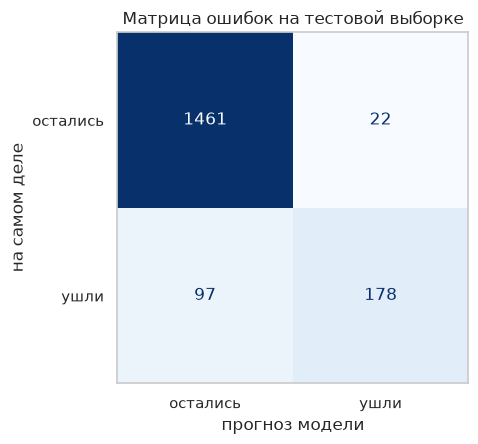

In [97]:
test_confusion = confusion_matrix(y_test, test_prediction)

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ConfusionMatrixDisplay(test_confusion, display_labels=['остались', 'ушли']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.grid(False)
ax.set(xlabel='прогноз модели', ylabel='на самом деле',
       title='Матрица ошибок на тестовой выборке')
plt.tight_layout()
plt.show()

**Что видно в матрице ошибок**

- Из 275 ушедших модель нашла 178, пропустила 97: полнота 0.647
- Ложных тревог всего 22 из 1483 оставшихся
- Для "ТелеДома" пропуск ушедшего дороже ложной тревоги, а порог 0.5 консервативен: отдаёт точность 0.890 ценой полноты

Слева кривая "полнота–точность" по всем порогам с отметкой рабочего порога 0.5 и линией доли ушедших в тесте, справа те же метрики столбиками. Кривая диагностическая, выбирать по ней порог нельзя, иначе тест превратится в ещё одну валидацию

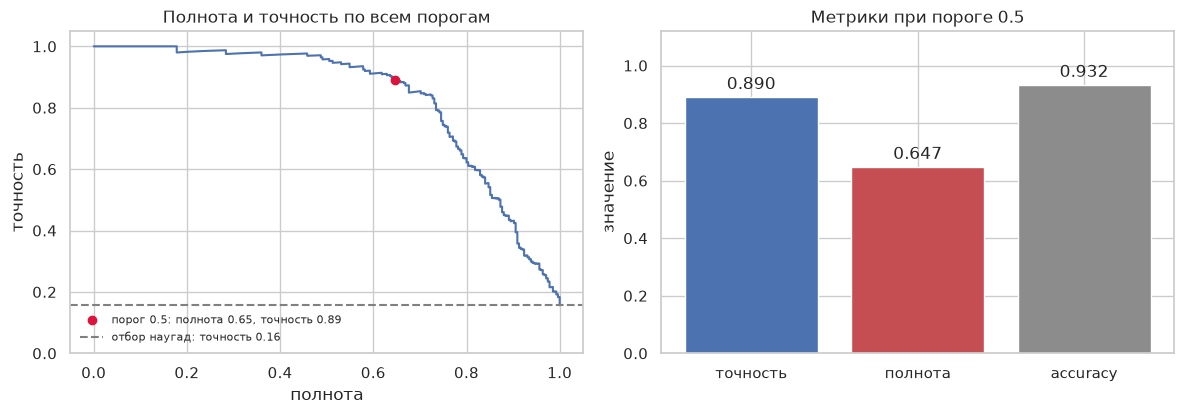

In [98]:
true_negative, false_positive, false_negative, true_positive = test_confusion.ravel()
threshold_precision = true_positive / (true_positive + false_positive)
threshold_recall = true_positive / (true_positive + false_negative)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(recall_curve, precision_curve, color='#4C72B0')
axes[0].scatter(threshold_recall, threshold_precision, color='crimson', zorder=3,
                label=f'порог 0.5: полнота {threshold_recall:.2f}, точность {threshold_precision:.2f}')
axes[0].axhline(y_test.mean(), color='grey', linestyle='--',
                label=f'отбор наугад: точность {y_test.mean():.2f}')
axes[0].set(xlabel='полнота', ylabel='точность', ylim=(0, 1.05),
            title='Полнота и точность по всем порогам')
axes[0].legend(loc='lower left', fontsize=8, frameon=False)

metric_bars = axes[1].bar(['точность', 'полнота', 'accuracy'],
                          [threshold_precision, threshold_recall, test_accuracy],
                          color=['#4C72B0', '#C44E52', '#8C8C8C'])
axes[1].bar_label(metric_bars, fmt='%.3f', padding=3)
axes[1].set(ylim=(0, 1.12), ylabel='значение', title='Метрики при пороге 0.5')
plt.tight_layout()
plt.show()

**Что видно по полноте и точности**

- Кривая держит точность выше 0.85 примерно до полноты 0.7, дальше обрыв. Последние ушедшие достаются ценой лавины ложных тревог
- Рабочая точка порога 0.5, полнота 0.65 при точности 0.89, стоит далеко от отбора наугад с его точностью 0.16
- Порог для кампании удержания надо выбирать по стоимости ошибок, а не оставлять 0.5 по умолчанию

**Промежуточный вывод по разделу**

- Порог ТЗ взят. ROC-AUC на тесте 0.9306 при требуемых 0.85, accuracy 0.9323
- На тест ушла одна модель, одиночный `CatBoost` на нативных категориях
- Матрица ошибок и кривая полноты с точностью сходятся с ROC-AUC: 178 найденных ушедших из 275 при 22 ложных тревогах
- Главный вклад по SHAP даёт `life_span`, признак ретроспективный, поэтому число оптимистично относительно живых данных

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> плюс за раздел, понятно как модель принимает решение. В будущем можно оставить наиболее значимые признаки и посмотреть на качество модели.

## 11. Выводы

Задача: найти клиентов, расторгающих договор. Данные это выгрузка из четырёх таблиц Sqlite на 1 февраля 2020 года, требование ТЗ ROC-AUC не меньше 0.85 на тесте.

- **Данные.** Всё пришло текстом, типы привёл к рабочим, имена столбцов к snake_case. 11 значений `total_charges` оказались пробелом-заглушкой, все они договоры дня выгрузки, неинформативные удалил, это 0.16% выборки. Четыре таблицы соединил по `customer_id` с `validate='one_to_one'`, вышло 7032 строки и 24 столбца. Цель `churn` выделил из `end_date`: 1101 ушедший против 5931 оставшегося, 15.7% против 84.3%
- **EDA.** Сильных связей с целью нет: максимум 0.374 у `life_span` и 0.371 у `contract_duration`. `gender`, `dependents` и `internet_service` отсеял в 6.3 по числам: phik с целью 0.009, 0.049 и 0.056, при этом флаг `has_internet` выведен из `internet_service` (1.000) и связан с оттоком сильнее, 0.114, а `dependents` дублирует `partner` (0.652). Из четырёх кандидатов нетривиален один, `services_count`
- **Модели.** Шесть поисков через `OptunaSearchCV` на one-hot, седьмой `CatBoost` с нативными категориями, плюс ранговый ансамбль трёх семейств. Волны на one-hot дали от 0.7960 до 0.8934, `CatBoost` 0.9219, ансамбль 0.8819. Вес редкого класса подбору не понадобился, `auto_class_weights` остался 'None'
- **Финальная модель.** По правилу, зафиксированному до вскрытия теста, "CatBoost, нативные категории" с CV ROC-AUC 0.9219
- **Тест.** ROC-AUC 0.9306, accuracy 0.9323, порог ТЗ 0.85 пройден с запасом 0.0806
- **Цена метрики.** Качество держится на `life_span`, который у ушедших посчитан до их даты расторжения, поэтому offline-оценка оптимистична

In [99]:
final_leaderboard = leaderboard[['CV ROC-AUC']].copy()
final_leaderboard['до порога 0.85'] = (0.85 - final_leaderboard['CV ROC-AUC']).round(4)
final_leaderboard['кандидат на тест'] = np.where(final_leaderboard.index == final_model_name,
                                                 'да, один прогон', '—')

final_leaderboard.sort_values('CV ROC-AUC', ascending=False).round(4)

,CV ROC-AUC,до порога 0.85,кандидат на тест
модель,,,
"CatBoost, нативные категории",0.9219,-0.0719,"да, один прогон"
"HistGB, компактный поиск",0.8934,-0.0434,—
ансамбль рангов трёх семейств,0.8819,-0.0319,—
"GradientBoosting, широкий поиск",0.8543,-0.0043,—
"нейросеть, широкий поиск",0.8283,0.0217,—
"нейросеть, компактный поиск",0.8270,0.0230,—
"дерево, широкий поиск",0.7969,0.0531,—
"дерево, компактный поиск",0.7960,0.0540,—
бейзлайн DummyClassifier,0.5000,0.3500,—


**Почему `life_span` в наборе, а возраст договора от даты среза запрещён**

- **Признак легален.** ТЗ разрешает производные `begin_date`, названные поимённо, и требует, чтобы в `X` их была ровно одна. В наборе одна, `life_span`: дневная шкала точнее месячной, `contract_duration` остался только для разведочного анализа
- **Цена признака.** У ушедшего срок считается до `end_date`, из которого собран `churn`, а у действующего граница одна на всех, поэтому дневная шкала несёт след самой даты ухода. Offline-оценка на эту величину оптимистична
- **Весь класс "от `begin_date` до фиксированной даты среза" из работы исключён.** `end_date` в такой формуле не участвует, но разность "возраст от среза − `total_charges / monthly_charges`" равна нулю у тех, кто платит до сих пор, и заметно больше нуля у ушедших, то есть это сама цель в обход `end_date`. Ранний вариант работы такую замену содержал и был отозван как утечка
- **Ограничение постановки.** Цель кумулятивная. `churn` отвечает на вопрос "был ли договор расторгнут когда-либо до 1 февраля 2020", поэтому модель описывает историческую выгрузку, а не предсказывает будущее
- **Порядок отбора признаков.** Скрининг по phik и решения о наборе я делал по всей объединённой таблице, до сплита. Такой порядок задан самим ТЗ. В более строгой постановке они принимались бы только на тренировочной части

Главный урок: **высокая метрика сама по себе ничего не доказывает, сначала нужно понять, какая часть метрики держится на признаках, восстанавливающих бизнес цель**

**Как улучшать модель дальше**

- **Переформулировать задачу через отсечки и окно прогноза.** Несколько исторических дат, на каждую только действующие клиенты, признаки по состоянию на отсечку, цель "уйдёт ли в следующие N месяцев". В такой постановке возраст договора становится законным признаком
- **Добавить внешние данные.** Обращения в поддержку, аварии по адресу, изменения трафика, смены тарифа, просрочки платежей
- **Калибровать вероятности,** для расчёта выгоды кампании нужен не порядок клиентов, а сама вероятность
- **Выбирать порог по стоимости ошибок,** а не брать 0.5 по умолчанию
- **Следить за дрейфом.** Распределения признаков, уровень оттока по когортам, качество на свежих отсечках

**Рекомендации "ТелеДому"**

Всё ниже это наблюдения об уже случившемся оттоке в исторической выгрузке, а не прогноз. Читать их стоит как гипотезы для проверки на живых данных

- **Основной риск не новички, а середина шкалы срока.** До 7 месяцев расторгли 5.0%, на сроке 8–18 месяцев 14.3%, от полутора до четырёх с половиной лет 27%. У самых долгих договоров, 54–76 месяцев, 5.5%, но это не лояльность ветеранов, а свойство выгрузки. Чтобы попасть в эту полосу, договор должен был до неё дожить. Работать надо с середним возрастом клиентов
- **Самый рискованный сегмент это взрослый клиент с большим пакетом услуг и высоким счётом.** При сроке 25–48 месяцев ушли 57.2% клиентов с шестью-семью услугами (145 человек) и 36.1% с четырьмя-пятью (610 человек) против 18.7% с нулём-одной. По деньгам так же: верхний квинтиль месячного платежа, свыше 94.3, дал 26.7% против 9.8% в нижнем. Гипотеза "большой пакет удерживает" не подтвердилась, скорее наоборот
- **Длинный договор сам по себе не удерживает.** В целом помесячные выглядят лояльнее, 10.5% против 21.3% у годовых и 22.6% у двухлетних, но это эффект стажа. Медиана 12 месяцев против 37 и 55. Внутри стажа 1–24 месяца картина обратная: 7.4% помесячных против 25.5% годовых и 39.0% двухлетних
- **Способ оплаты сегментирует, но неожиданно.** Бумажный чек остаётся самой лояльной группой и в срезе стажа больше двух лет: 10.7% против 21.5% у банковского перевода, 21.9% у электронного чека и 19.8% у карты. Автоплатёж барьером не работает, `payment_automatic` не подтвердился ни в скрининге, ни в разрезке по стажу
- **Точного списка от модели не стоит ждать.** Качество держится на ретроспективном `life_span`, поэтому offline-оценки (CV 0.9219, тест 0.9306) оптимистичны: на живых данных стоит ждать заметно ниже, и списка "кому слать промокод" с приемлемой ценой ошибки такая модель не даёт. Рабочий инструмент сегодня это маркетинговые активности по сегментам, описанным выше
- **Копить данные под будущую модель уже сейчас.** Помесячные снимки состояния клиента, обращения в поддержку, инциденты, смены тарифа. Без истории любая модель на такой выгрузке будет объяснять прошлое лучше, чем предсказывать будущее

*Примечание.* Финальная метрика держится на дневной шкале срока жизни договора: SHAP отдаёт `life_span` 27.8% всего объяснения, а эта шкала частично считывает уже случившийся уход. Это ограничение работы, а не находка

<div style="border:solid Chocolate 2px; padding: 40px">

<h2>✔️ Заключение ментора: <a class="tocSkip"> </h2> 
    
<b>Ярослав</b>, работа почти готова, осталась небольшая доработка, не влияющая на результат, мои комментарии ты увидишь выше.

Жду твою работу! :)